In [2]:
!git clone https://github.com/zhu-xlab/DOFA.git

fatal: destination path 'DOFA' already exists and is not an empty directory.


In [3]:
%cd DOFA

/home/arm/Desktop/ARM/Codes/DOFA


/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [5]:
%run checkpoints/download_weights.py

/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
%pip install kornia

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install "numpy<2.0"

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import kornia.augmentation as K
import kornia.augmentation.container as C
import rasterio
import numpy as np

S1_MEAN = [166.36275909, 88.45542715]
S1_STD = [64.83126309, 43.07350145]

class DataAugmentation(torch.nn.Module):
    def __init__(self, mean, std, image_size=224):
        super().__init__()
        # Use container.AugmentationSequential (latest API)
        self.aug = C.AugmentationSequential(
            K.RandomResizedCrop(
                size=(image_size, image_size),
                scale=(0.8, 1.0),
                ratio=(0.9, 1.1),
                                        ),
            # Add more if you want:
            # K.RandomHorizontalFlip(p=0.5),
            # K.RandomVerticalFlip(p=0.5),
            data_keys=["input", "mask"],  # Ensures identical transform
        )

        self.normalize = K.Normalize(mean=mean, std=std)

    @torch.no_grad()
    def forward(self, x, y):
        x, y = self.aug(x, y)
        x = self.normalize(x)
        return x, y

/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/kornia/feature/lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [7]:
transform = DataAugmentation(mean=S1_MEAN, std=S1_STD)


def preprocess_s1(vh_path, vv_path, label_path):
    with rasterio.open(vh_path) as f1:
        vh = f1.read()
    with rasterio.open(vv_path) as f2:
        vv = f2.read()

    s1_img = np.concatenate((vh, vv), 0).astype('float32')
    s1_img = torch.from_numpy(s1_img).unsqueeze(0)  # [1, 2, H, W]

    with rasterio.open(label_path) as f3:
        label = torch.from_numpy(f3.read().astype('float32')).unsqueeze(0)  # [1, 1, H, W]
    s1_img, label = transform(s1_img, label)
    return s1_img.squeeze(0), label.squeeze(0)


/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


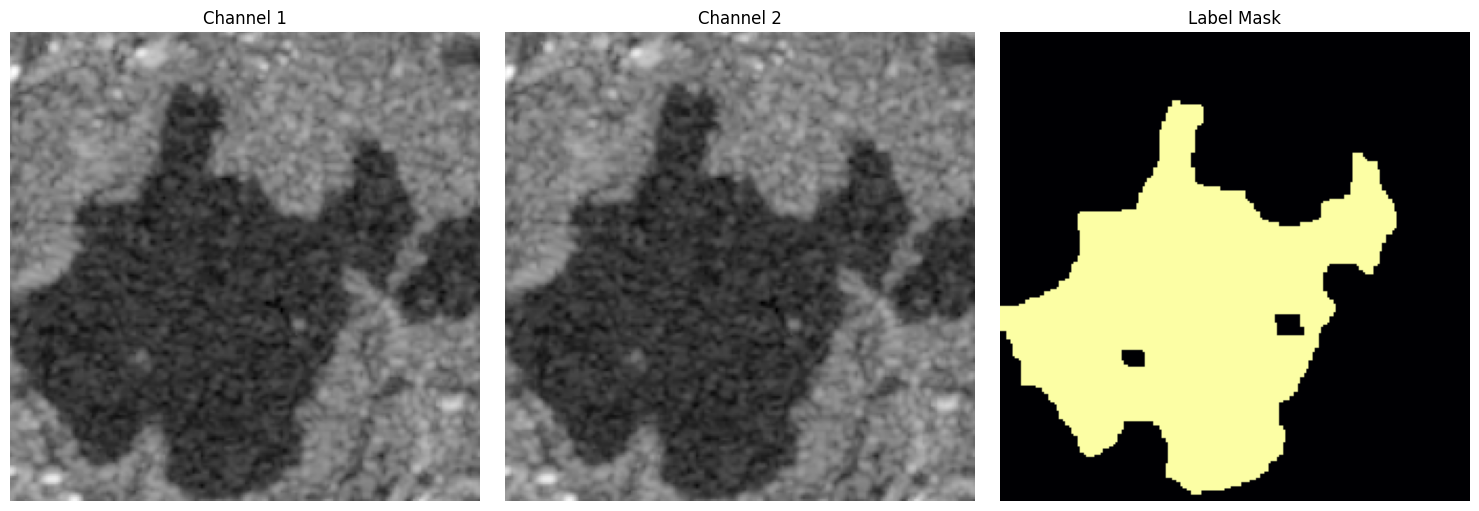

Final tensor shape: torch.Size([1, 2, 224, 224])
Label shape: torch.Size([1, 224, 224])


In [8]:
import matplotlib.pyplot as plt

image1 = r"/home/arm/Documents/ARM/8bit_png/vh/FID0_Q1_2015_S1_Reservoir_Batch_01_170925.png"
image2 = r"/home/arm/Documents/ARM/8bit_png/vh/FID0_Q1_2015_S1_Reservoir_Batch_01_170925.png"
label = r"/home/arm/Documents/ARM/8bit_png/labels/FID0_Q1_2015_S1_Reservoir_Batch_01_170925_ensemble_cleaned.png"

s1_img, label = preprocess_s1(image1, image2, label)

# ------------------ Visualization ------------------ #
C, H, W = s1_img.shape
fig, axes = plt.subplots(1, C + 1, figsize=(5 * (C + 1), 5))

for i in range(C):
    axes[i].imshow(s1_img[i].cpu(), cmap="gray")
    axes[i].set_title(f"Channel {i+1}")
    axes[i].axis("off")

axes[-1].imshow(label[0].cpu(), cmap="inferno")
axes[-1].set_title("Label Mask")
axes[-1].axis("off")

plt.tight_layout()
plt.show()

# Model-ready tensor
s1_img = s1_img.unsqueeze(0)  # [1, 2, 224, 224]
print("Final tensor shape:", s1_img.shape)
print("Label shape:", label.shape)

In [9]:
%pip install timm

Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
from dofa_v1 import vit_base_patch16

# 1. Add map_location to load the model onto the CPU
check_point = torch.load(
    '/home/arm/Desktop/ARM/Codes/DOFA/checkpoints/DOFA_ViT_base_e100_full_weight.pth', 
    map_location=torch.device('cpu'),
    weights_only=False
)

vit_model = vit_base_patch16(img_size=224)
vit_loaded = vit_model.load_state_dict(check_point, strict=False)
# missing_keys=['fc_norm.weight', 'fc_norm.bias', 'head.weight', 'head.bias'], unexpected_keys=['mask_token', 'norm.weight', 'norm.bias', 'projector.weight', 'projector.bias']

# 2. Remove or comment out this line, as CUDA is not available
# vit_model = vit_model.cuda() 

# You can now proceed with the model on the CPU
print(vit_loaded)

_IncompatibleKeys(missing_keys=['cls_token', 'pos_embed', 'fc_norm.weight', 'fc_norm.bias', 'patch_embed.weight_generator.weight_tokens', 'patch_embed.weight_generator.bias_token', 'patch_embed.weight_generator.transformer_encoder.layers.0.self_attn.in_proj_weight', 'patch_embed.weight_generator.transformer_encoder.layers.0.self_attn.in_proj_bias', 'patch_embed.weight_generator.transformer_encoder.layers.0.self_attn.out_proj.weight', 'patch_embed.weight_generator.transformer_encoder.layers.0.self_attn.out_proj.bias', 'patch_embed.weight_generator.transformer_encoder.layers.0.linear1.weight', 'patch_embed.weight_generator.transformer_encoder.layers.0.linear1.bias', 'patch_embed.weight_generator.transformer_encoder.layers.0.linear2.weight', 'patch_embed.weight_generator.transformer_encoder.layers.0.linear2.bias', 'patch_embed.weight_generator.transformer_encoder.layers.0.norm1.weight', 'patch_embed.weight_generator.transformer_encoder.layers.0.norm1.bias', 'patch_embed.weight_generator.t

In [12]:
wavelengths = [3.75, 3.75]
out_feat = vit_model.forward_features(s1_img, wave_list=wavelengths)
out_logits = vit_model.forward(s1_img, wave_list=wavelengths)
print(out_feat.shape)
print(out_logits.shape)

torch.Size([1, 768])
torch.Size([1, 45])


In [13]:
vit_model.eval()

OFAViT(
  (fc_norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (patch_embed): Dynamic_MLP_OFA(
    (weight_generator): TransformerWeightGenerator(
      (transformer_encoder): TransformerEncoder(
        (layers): ModuleList(
          (0): TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
            )
            (linear1): Linear(in_features=128, out_features=2048, bias=True)
            (dropout): Dropout(p=False, inplace=False)
            (linear2): Linear(in_features=2048, out_features=128, bias=True)
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=False, inplace=False)
            (dropout2): Dropout(p=False, inplace=False)
          )
        )
      )
      (fc_weight): Linear(in_features=128, out_features=

In [14]:
features=[]
def get_features_hook(module, input, output):
    """Hook to capture the output of the specified layer."""
    # We only want the patch tokens, not the [CLS] token, hence [:, 1:, :]
    features.append(output[:,1:,:].detach().cpu())
# The handle is used to remove the hook later.
handle = vit_model.blocks[11].register_forward_hook(get_features_hook)
vit_model.forward(s1_img, wave_list=wavelengths)

tensor([[-0.1226, -0.0550, -0.3296,  0.6256, -0.6847,  0.4226, -0.5307,  0.0302,
          0.4556, -0.1823,  0.2912, -0.0510, -0.2541,  0.7278,  0.2306, -0.7499,
         -0.7366, -0.4253,  0.9054, -0.1861,  0.2312, -0.1491, -0.4477,  0.4109,
          0.4050, -0.1339, -0.7938, -0.4415, -0.5252, -0.4161,  0.2894,  0.8932,
         -0.3221,  0.3442, -0.2175,  0.4383, -0.0069,  0.0014,  0.2494,  0.8410,
          0.2500, -0.2616, -1.1545,  0.0507, -0.2182]],
       grad_fn=<AddmmBackward0>)

In [15]:
features[0]  # should be [1,196,768] for vit_base_patch16

tensor([[[-1.0725, -1.6038, -0.4576,  ...,  1.5536, -0.1600,  1.6671],
         [-0.9273, -1.6414, -0.3956,  ...,  1.7267, -0.0806,  1.9001],
         [-1.1709, -1.7428, -0.4667,  ...,  1.8597, -0.1026,  1.9004],
         ...,
         [-1.2816, -1.8752, -0.3291,  ...,  1.3937,  0.1549,  1.9829],
         [-1.0306, -1.7798, -0.4064,  ...,  1.6277, -0.0901,  1.9338],
         [-0.9573, -1.6435, -0.5928,  ...,  1.6568, -0.0214,  1.8560]]])

In [53]:
features[0].shape

torch.Size([1, 196, 768])

In [54]:
handle.remove()

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleUNetDecoder(nn.Module):
    def __init__(self, embed_dim=768, patch_size=18, out_channels=3):
        super().__init__()
        # Assume input: [B, 196, 768] → reshape to [B, 768, 14, 14]
        self.patch_size = patch_size

        self.up1 = nn.ConvTranspose2d(embed_dim, 256, 2, stride=2)  # 14 → 28
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)        # 28 → 56
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)         # 56 → 112
        self.up4 = nn.ConvTranspose2d(64, 32, 2, stride=2)          # 112 → 224
        self.out_conv = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        # x: [B, 196, 768]
        B, N, C = x.shape
        H = W = int(N ** 0.5)  # 14 for ViT
        x = x.permute(0, 2, 1).reshape(B, C, H, W)  # [B, 768, 14, 14]

        x = F.relu(self.up1(x))
        x = F.relu(self.up2(x))
        x = F.relu(self.up3(x))
        x = F.relu(self.up4(x))
        x = self.out_conv(x)
        return x

# -------------------------------
# Test
# -------------------------------
x = features[0]
decoder = SimpleUNetDecoder(embed_dim=768, patch_size=18, out_channels=3)
y = decoder(x)
print("Input:", x.shape)
print("Output:", y.shape)

Input: torch.Size([1, 196, 768])
Output: torch.Size([1, 3, 224, 224])


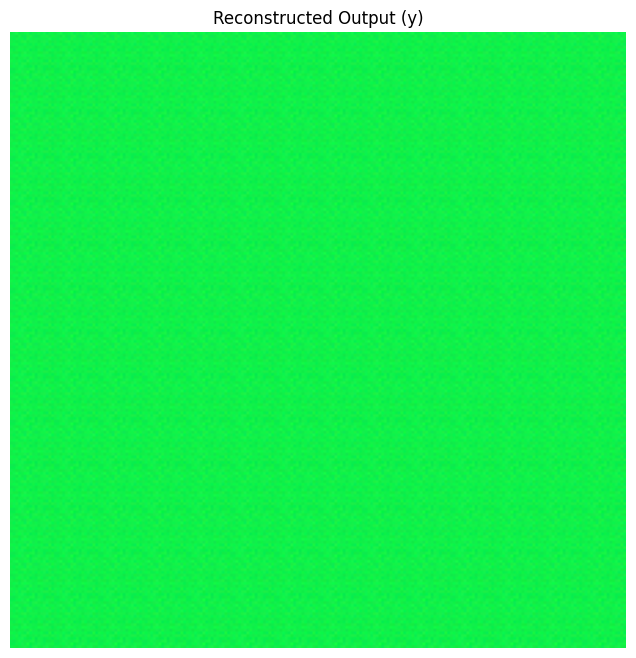

In [17]:
img = y.detach().cpu().squeeze(0)       # [3, H, W]
img = img.permute(1, 2, 0).numpy()      # [H, W, 3]

# optional normalization (if not in [0,1])
img = (img - img.min()) / (img.max() - img.min())

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Reconstructed Output (y)")
plt.show()

In [4]:
import torch
from torch import nn
wavelengths = [3.75, 3.75]  # Example wavelengths for Sentinel-1 VH and VV bands
def extract_patch_features(
    model: nn.Module,
    image_tensor: torch.Tensor,
    wavelengths: list,
) -> torch.Tensor:
    """
    Extracts intermediate patch features from a specific layer of a Vision Transformer.

    This function registers a forward hook to capture the output of the target layer,
    runs a forward pass to trigger the hook, and then removes the hook. It is designed
    to be called within a training loop for a decoder or other downstream tasks.

    Args:
        model (nn.Module): The pre-trained Vision Transformer model (e.g., DOFA).
        image_tensor (torch.Tensor): The preprocessed input image tensor with batch dimension.
        wavelengths (list): The list of wavelengths corresponding to the image channels.
        target_layer (nn.Module): The specific layer from which to extract features 
                                  (e.g., model.blocks[1]).

    Returns:
        torch.Tensor: A tensor containing the extracted patch features from the specified
                      layer, detached from the computation graph and on the CPU.
    """
    # A list to store the features captured by the hook
    features = []

    def get_features_hook(module, input, output):
        """Hook to capture the output, discard the token, and store it."""
        # The slice [:, 1:, :] removes the token from the output
        features.append(output[:, 1:, :].detach().cpu())

    # Register the forward hook on the target layer
    handle = model.blocks[11].register_forward_hook(get_features_hook)

    # Run a forward pass in inference mode to trigger the hook
    with torch.no_grad():
        model.forward(image_tensor, wave_list=wavelengths)

    # It's crucial to remove the hook after use to avoid unintended side effects
    handle.remove()

    if not features:
        raise RuntimeError("Hook did not capture any features. The forward pass might have failed.")
        
    return features[0]

In [19]:
features= patch_features = extract_patch_features(model=vit_model,image_tensor=s1_img,wavelengths=wavelengths)

Pipeline

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from tqdm import tqdm
from typing import List, Tuple, Optional
import os
from PIL import Image
import rasterio

In [4]:
wavelengths = [3.75, 3.75]  # Example wavelengths for Sentinel-1 VH and VV bands

def extract_patch_features(
    model: nn.Module,
    image_tensor: torch.Tensor,
    wavelengths: list,
    block_indices: list = [3, 5, 7, 11],  # 0-indexed blocks
) -> dict:
    """
    Extracts intermediate patch features from multiple layers of a Vision Transformer.
    
    Args:
        model: The pre-trained Vision Transformer model (e.g., DOFA)
        image_tensor: The preprocessed input image tensor with batch dimension
        wavelengths: The list of wavelengths corresponding to the image channels
        block_indices: List of block indices to extract features from (0-indexed)
        
    Returns:
        Dictionary with block indices as keys and patch features (B, N, D) as values
        where N is number of patches and D is embedding dimension
    """
    features = {}

    def get_features_hook(name):
        def hook(module, input, output):
            # Remove CLS token (first token) and store patch features
            features[name] = output[:, 1:, :].detach()
        return hook

    # Register hooks on multiple blocks
    handles = []
    for idx in block_indices:
        handle = model.blocks[idx].register_forward_hook(
            get_features_hook(f'block_{idx}')
        )
        handles.append(handle)

    # Forward pass
    with torch.no_grad():
        model.forward(image_tensor, wave_list=wavelengths)

    # Remove all hooks
    for handle in handles:
        handle.remove()

    if not features:
        raise RuntimeError("Hooks did not capture any features.")
    
    # Verify all blocks captured features
    for idx in block_indices:
        if f'block_{idx}' not in features:
            raise RuntimeError(f"Block {idx} did not capture features.")
        
    return features

In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import pandas as pd
import rasterio
from pathlib import Path
import kornia.augmentation as K

# SMP Imports
from segmentation_models_pytorch.decoders.upernet.decoder import UPerNetDecoder
from segmentation_models_pytorch.base import SegmentationHead

# Import your specific model
from dofa_v1 import vit_base_patch16

# ============================================================================
# 1. Feature Extraction Helper (The Bridge)
# ============================================================================

class ViTFeatureExtractor:
    """
    Attaches hooks to the ViT to extract specific block outputs 
    required by DOFAUPerNet.
    """
    def __init__(self, model, hook_indices=[3, 5, 7, 11]):
        self.model = model
        self.hook_indices = hook_indices
        self.features = {}
        self.hooks = []
        
        # Register hooks
        for idx in hook_indices:
            # Adjust layer naming based on timm/dofa implementation
            # Usually model.blocks[i]
            layer = model.blocks[idx]
            self.hooks.append(layer.register_forward_hook(self._get_hook(f'block_{idx}')))

    def _get_hook(self, name):
        def hook(model, input, output):
            # output is usually (batch, sequence, dim)
            self.features[name] = output
        return hook

    def clear(self):
        self.features = {}

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()

def extract_patch_features(model, images, wavelengths, feature_extractor):
    """
    Runs forward pass and retrieves intermediate features.
    """
    feature_extractor.clear()
    
    # Run the model (Forward pass)
    # Note: We don't need the final output, just the side effects (hooks)
    _ = model(images, wavelengths)
    
    return feature_extractor.features

/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/kornia/feature/lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [6]:
pip install segmentation-models-pytorch

Note: you may need to restart the kernel to use updated packages.


In [7]:
import segmentation_models_pytorch as smp
print(smp.__version__)
print(dir(smp))


0.5.0
['DPT', 'DeepLabV3', 'DeepLabV3Plus', 'FPN', 'Linknet', 'MAnet', 'MODEL_ARCHITECTURES_MAPPING', 'PAN', 'PSPNet', 'Segformer', 'UPerNet', 'Unet', 'UnetPlusPlus', '_MODEL_ARCHITECTURES', '_Optional', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_torch', 'base', 'create_model', 'datasets', 'decoders', 'encoders', 'from_pretrained', 'losses', 'metrics']


In [8]:
class DOFAUPerNet(nn.Module):
    """
    UPerNet decoder for DOFA ViT encoder using SMP's UPerNetDecoder.
    """
    def __init__(
        self,
        encoder_dim: int = 768,
        decoder_channels: int = 256,
        num_classes: int = 2,
        patch_size: int = 16,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.encoder_dim = encoder_dim
        
        # Encoder channels: [input, block_3, block_5, block_7, block_11]
        # input (3) + 4 blocks
        encoder_channels = [3, encoder_dim, encoder_dim, encoder_dim, encoder_dim]
        
        # Project ViT features to common dimension
        self.feature_proj = nn.ModuleDict({
            'block_3': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_5': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_7': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_11': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
        })
        
        # SMP UPerNet decoder
        self.decoder = UPerNetDecoder(
            encoder_channels=encoder_channels,
            encoder_depth=4,
            decoder_channels=decoder_channels,
            use_norm="batchnorm",
        )
        
        # Segmentation head
        self.segmentation_head = SegmentationHead(
            in_channels=decoder_channels,
            out_channels=num_classes,
            activation=None,
            kernel_size=1,
            upsampling=4, 
        )
        
        self.dropout = nn.Dropout2d(dropout)
    
    def reshape_vit_features(self, features: torch.Tensor, H: int, W: int) -> torch.Tensor:
        """Reshape ViT features from (B, N, D) to (B, D, H, W)."""
        B, N, D = features.shape
        # Handle Class Token if present (DOFA usually doesn't output it in blocks, but safe check)
        if N == (H * W) + 1:
            features = features[:, 1:, :] # Drop cls token
        
        return features.transpose(1, 2).reshape(B, D, H, W)
    
    def forward(
        self, 
        features_dict: dict, 
        target_size: tuple,
        dummy_input: torch.Tensor = None
    ) -> torch.Tensor:
        
        # Determine spatial dimensions from the deepest feature
        B, N, D = features_dict['block_11'].shape
        # Assuming square image and N = H*W (or H*W+1)
        H = W = int(np.sqrt(N)) if N % int(np.sqrt(N)) == 0 else int(np.sqrt(N - 1))
        
        # Reshape and project all features
        feat_3 = self.feature_proj['block_3'](
            self.reshape_vit_features(features_dict['block_3'], H, W)
        )
        feat_5 = self.feature_proj['block_5'](
            self.reshape_vit_features(features_dict['block_5'], H, W)
        )
        feat_7 = self.feature_proj['block_7'](
            self.reshape_vit_features(features_dict['block_7'], H, W)
        )
        feat_11 = self.feature_proj['block_11'](
            self.reshape_vit_features(features_dict['block_11'], H, W)
        )
        
        # Handle Dummy Input (The "Stem" or Image input)
        if dummy_input is None:
            # Fallback if not provided
            dummy_input = torch.zeros(B, 3, H, H, device=feat_3.device)
        else:
            # Interpolate raw image to feature map size (e.g. 14x14)
            # This corresponds to "skip connection 0" in UPerNet logic
            dummy_input = F.interpolate(
                dummy_input, 
                size=(H, H), 
                mode='bilinear', 
                align_corners=False
            )
        
        # Construct list for SMP
        features_list = [dummy_input, feat_3, feat_5, feat_7, feat_11]
        
        # Decoder Pass
        decoder_out = self.decoder(features_list)
        x = self.dropout(decoder_out)
        x = self.segmentation_head(x)
        
        # Final Upsample
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
        
        return x

In [9]:
from torch.amp import autocast, GradScaler
S1_MEAN = [166.36275909, 88.45542715]
S1_STD = [64.83126309, 43.07350145]

class GPUAugmentation(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.normalize = K.Normalize(mean=torch.tensor(mean), std=torch.tensor(std))

    def forward(self, x):
        return self.normalize(x)

class SegmentationTrainer:
    def __init__(
        self,
        vit_model: nn.Module,
        decoder: nn.Module,
        train_loader,
        wavelengths: list, 
        device: str = 'cuda',
        encoder_lr: float = 1e-5,
        decoder_lr: float = 3e-4,
        num_epochs: int = 100,
        checkpoint_dir: str = 'checkpoints',
    ):
        self.vit_model = vit_model.to(device)
        self.decoder = decoder.to(device)
        self.train_loader = train_loader
        self.wavelengths = wavelengths 
        self.device = device
        self.num_epochs = num_epochs
        self.checkpoint_dir = checkpoint_dir

        # Helper to get layers out of ViT
        self.extractor_hook = ViTFeatureExtractor(self.vit_model, hook_indices=[3, 5, 7, 11])

        self.augmentor = GPUAugmentation(mean=S1_MEAN, std=S1_STD).to(device)
        
        # Unfreeze
        self.vit_model.train()
        for param in self.vit_model.parameters():
            param.requires_grad = True 
        
        # Optimizer
        optimizer_grouped_parameters = [
            {'params': self.vit_model.parameters(), 'lr': encoder_lr},
            {'params': self.decoder.parameters(), 'lr': decoder_lr}
        ]
        
        self.optimizer = AdamW(optimizer_grouped_parameters, weight_decay=0.01)
        self.scheduler = CosineAnnealingLR(self.optimizer, T_max=num_epochs)
        self.history = []
        self.criterion = nn.CrossEntropyLoss()
        self.scaler = GradScaler('cuda')
        self.best_train_iou = 0.0
        
        os.makedirs(checkpoint_dir, exist_ok=True)
    
    def train_epoch(self, epoch: int) -> dict:
        self.decoder.train()
        self.vit_model.train()
        
        total_loss, total_iou = 0.0, 0.0
        
        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{self.num_epochs} [Train]')
        for batch in pbar:
            images = batch['image'].to(self.device, non_blocking=True)
            masks = batch['mask'].long().squeeze(1).to(self.device, non_blocking=True)
            
            # 1. Normalize on GPU
            images = self.augmentor(images)
            images = images.contiguous()

            # 2. Extract features using hooks
            # Note: We pass original images to model, but we might want normalized ones
            # usually ViT expects normalized.
            with autocast('cuda'):
                features_dict = extract_patch_features(
                    self.vit_model, images, self.wavelengths, self.extractor_hook
                )
                # Create dummy input for shape reference
                target_size = masks.shape[-2:]
                logits = self.decoder(features_dict, target_size, dummy_input=images)
                loss = self.criterion(logits, masks)
            
            self.optimizer.zero_grad()
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            iou = self.compute_iou(logits, masks)
            total_loss += loss.item()
            total_iou += iou
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'IoU': f'{iou:.4f}'})
        
        return {'loss': total_loss / len(self.train_loader), 'iou': total_iou / len(self.train_loader)}

    def compute_iou(self, logits, masks):
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            num_classes = logits.shape[1]
            iou_per_class = []
            for cls in range(num_classes):
                pred_cls = (preds == cls)
                mask_cls = (masks == cls)
                intersection = (pred_cls & mask_cls).sum().float()
                union = (pred_cls | mask_cls).sum().float()
                if union > 0:
                    iou_per_class.append((intersection / union).item())
        return np.mean(iou_per_class) if iou_per_class else 0.0
    
    def save_checkpoint(self, epoch, metrics, is_best=False):
        checkpoint = {
            'epoch': epoch,
            'encoder_state_dict': self.vit_model.state_dict(),
            'decoder_state_dict': self.decoder.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'metrics': metrics,
        }
        torch.save(checkpoint, os.path.join(self.checkpoint_dir, f'ckpt_epoch_{epoch}.pth'))
        if is_best:
            torch.save(checkpoint, os.path.join(self.checkpoint_dir, 'best_model.pth'))
    
    def train(self):
        for epoch in range(self.num_epochs):
            metrics = self.train_epoch(epoch)
            self.scheduler.step()
            print(f"\nEpoch {epoch+1} - Loss: {metrics['loss']:.4f}, IoU: {metrics['iou']:.4f}")
            self.history.append({'epoch': epoch+1, **metrics})
            
            is_best = metrics['iou'] > self.best_train_iou
            if is_best: self.best_train_iou = metrics['iou']
            
            if (epoch + 1) % 10 == 0 or is_best:
                self.save_checkpoint(epoch, metrics, is_best)
                
        pd.DataFrame(self.history).to_csv(os.path.join(self.checkpoint_dir, 'history.csv'), index=False)
        print(f"Done. Best IoU: {self.best_train_iou:.4f}")


# -----------------------------
# 🔹 Segmentation Dataset
# -----------------------------
class SegmentationDataset(Dataset):
    def __init__(self, root_dir: str):
        self.root_dir = Path(root_dir)
        self.mask_paths = sorted(list(self.root_dir.glob("labels/*.png")))
        self.vv_dir = self.root_dir / "vv"
        self.vh_dir = self.root_dir / "vh"

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]
        filename = mask_path.name
        
        with rasterio.open(self.vv_dir / filename) as f:
            vv = f.read().astype('float32')
        with rasterio.open(self.vh_dir / filename) as f:
            vh = f.read().astype('float32')
        with rasterio.open(mask_path) as f:
            label = f.read().astype('float32')

        s1_img = np.concatenate((vv, vh), axis=0)
        return {"image": torch.from_numpy(s1_img), "mask": torch.from_numpy(label).long()}

In [ ]:
def main():
    config = {
        "encoder_dim": 768, "decoder_channels": 256, "num_classes": 2,
        "patch_size": 16, "image_size": 224, "batch_size": 100,
        "encoder_lr": 1e-5, "decoder_lr": 3e-4, "num_epochs": 100,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "head_dropout": 0.1
    }
    wavelengths = [3.75, 3.75]
    
    print("Loading ViT Encoder...")
    check_point = torch.load('/home/arm/Desktop/ARM/Codes/DOFA/checkpoints/DOFA_ViT_base_e100_full_weight.pth', weights_only=False)
    vit_model = vit_base_patch16(img_size=config['image_size'])
    vit_model.load_state_dict(check_point, strict=False)
    
    print("Preparing Data...")
    train_dataset = SegmentationDataset(root_dir='/home/arm/Documents/ARM/tiled_dataset')
    train_loader = DataLoader(
        train_dataset, batch_size=config['batch_size'], shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True
    )

    print("Initializing Decoder...")
    decoder = DOFAUPerNet(
        encoder_dim=config['encoder_dim'],
        decoder_channels=config['decoder_channels'],
        num_classes=config['num_classes'],
        dropout=config['head_dropout'],
        patch_size=config['patch_size']
    )

    print("Starting Training...")
    trainer = SegmentationTrainer(
        vit_model=vit_model,
        decoder=decoder,
        train_loader=train_loader,
        wavelengths=wavelengths,
        device=config['device'],
        encoder_lr=config['encoder_lr'],
        decoder_lr=config['decoder_lr'],
        num_epochs=config['num_epochs']
    )
    trainer.train()

if __name__ == "__main__":
    main()

discriminative learning dofa

In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import pandas as pd
import rasterio
from pathlib import Path
import kornia.augmentation as K
from torch.amp import autocast, GradScaler

# SMP Imports
from segmentation_models_pytorch.decoders.upernet.decoder import UPerNetDecoder
from segmentation_models_pytorch.base import SegmentationHead

# Import your specific model
from dofa_v1 import vit_base_patch16

# ============================================================================
# 1. Feature Extraction Helper
# ============================================================================

class ViTFeatureExtractor:
    def __init__(self, model, hook_indices=[3, 5, 7, 11]):
        self.model = model
        self.hook_indices = hook_indices
        self.features = {}
        self.hooks = []
        for idx in hook_indices:
            layer = model.blocks[idx]
            self.hooks.append(layer.register_forward_hook(self._get_hook(f'block_{idx}')))

    def _get_hook(self, name):
        def hook(model, input, output):
            self.features[name] = output
        return hook

    def clear(self):
        self.features = {}

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()

def extract_patch_features(model, images, wavelengths, feature_extractor):
    feature_extractor.clear()
    # Gradients allowed here for fine-tuning
    _ = model(images, wavelengths)
    return feature_extractor.features

# ============================================================================
# 2. Decoder
# ============================================================================

class DOFAUPerNet(nn.Module):
    def __init__(self, encoder_dim=768, decoder_channels=256, num_classes=2, patch_size=16, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        encoder_channels = [3, encoder_dim, encoder_dim, encoder_dim, encoder_dim]
        
        self.feature_proj = nn.ModuleDict({
            'block_3': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_5': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_7': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
            'block_11': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
        })
        
        self.decoder = UPerNetDecoder(
            encoder_channels=encoder_channels,
            encoder_depth=4,
            decoder_channels=decoder_channels,
            use_norm="batchnorm",
        )
        
        self.segmentation_head = SegmentationHead(
            in_channels=decoder_channels,
            out_channels=num_classes,
            activation=None,
            kernel_size=1,
            upsampling=4, 
        )
        self.dropout = nn.Dropout2d(dropout)
    
    def reshape_vit_features(self, features, H, W):
        B, N, D = features.shape
        if N == (H * W) + 1: features = features[:, 1:, :]
        return features.transpose(1, 2).reshape(B, D, H, W)
    
    def forward(self, features_dict, target_size, dummy_input=None):
        B, N, D = features_dict['block_11'].shape
        H = W = int(np.sqrt(N)) if N % int(np.sqrt(N)) == 0 else int(np.sqrt(N - 1))
        
        feat_3 = self.feature_proj['block_3'](self.reshape_vit_features(features_dict['block_3'], H, W))
        feat_5 = self.feature_proj['block_5'](self.reshape_vit_features(features_dict['block_5'], H, W))
        feat_7 = self.feature_proj['block_7'](self.reshape_vit_features(features_dict['block_7'], H, W))
        feat_11 = self.feature_proj['block_11'](self.reshape_vit_features(features_dict['block_11'], H, W))
        
        if dummy_input is None: dummy_input = torch.zeros(B, 3, H, H, device=feat_3.device)
        else: dummy_input = F.interpolate(dummy_input, size=(H, H), mode='bilinear', align_corners=False)
        
        features_list = [dummy_input, feat_3, feat_5, feat_7, feat_11]
        x = self.segmentation_head(self.dropout(self.decoder(features_list)))
        return F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)

# ============================================================================
# 3. Trainer & Utils
# ============================================================================

S1_MEAN = [166.36275909, 88.45542715]
S1_STD = [64.83126309, 43.07350145]

class GPUAugmentation(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.normalize = K.Normalize(mean=torch.tensor(mean), std=torch.tensor(std))
    def forward(self, x): return self.normalize(x)

class SegmentationTrainer:
    def __init__(self, vit_model, decoder, train_loader, wavelengths, device='cuda', 
                 encoder_lr=1e-5, decoder_lr=3e-4, num_epochs=100, checkpoint_dir='checkpoints/dofa_trainenc'):
        self.vit_model = vit_model.to(device)
        self.decoder = decoder.to(device)
        self.train_loader = train_loader
        self.wavelengths = wavelengths 
        self.device = device
        self.num_epochs = num_epochs
        self.checkpoint_dir = checkpoint_dir
        
        self.extractor_hook = ViTFeatureExtractor(self.vit_model, hook_indices=[3, 5, 7, 11])
        self.augmentor = GPUAugmentation(mean=S1_MEAN, std=S1_STD).to(device)
        
        self.vit_model.train()
        for param in self.vit_model.parameters(): param.requires_grad = True 
        
        self.optimizer = AdamW([
            {'params': self.vit_model.parameters(), 'lr': encoder_lr},
            {'params': self.decoder.parameters(), 'lr': decoder_lr}
        ], weight_decay=0.01)
        
        self.scheduler = CosineAnnealingLR(self.optimizer, T_max=num_epochs)
        self.criterion = nn.CrossEntropyLoss()
        self.scaler = GradScaler('cuda')
        self.best_train_iou = 0.0
        self.history = []
        os.makedirs(checkpoint_dir, exist_ok=True)
    
    def train_epoch(self, epoch):
        self.decoder.train()
        self.vit_model.train()
        total_loss, total_iou = 0.0, 0.0
        
        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{self.num_epochs}')
        for batch in pbar:
            images = batch['image'].to(self.device, non_blocking=True)
            masks = batch['mask'].long().squeeze(1).to(self.device, non_blocking=True)
            
            images = self.augmentor(images).contiguous()

            with autocast('cuda'):
                features_dict = extract_patch_features(self.vit_model, images, self.wavelengths, self.extractor_hook)
                logits = self.decoder(features_dict, masks.shape[-2:], dummy_input=images)
                loss = self.criterion(logits, masks)
            
            self.optimizer.zero_grad()
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            # Detach explicitly to save memory
            loss_item = loss.item()
            iou = self.compute_iou(logits.detach(), masks)
            total_loss += loss_item
            total_iou += iou
            
            pbar.set_postfix({'loss': f'{loss_item:.4f}', 'IoU': f'{iou:.4f}'})
        
        return {'loss': total_loss / len(self.train_loader), 'iou': total_iou / len(self.train_loader)}

    def compute_iou(self, logits, masks):
        preds = torch.argmax(logits, dim=1)
        num_classes = logits.shape[1]
        iou_per_class = []
        for cls in range(num_classes):
            pred_cls = (preds == cls)
            mask_cls = (masks == cls)
            intersection = (pred_cls & mask_cls).sum().float()
            union = (pred_cls | mask_cls).sum().float()
            if union > 0: iou_per_class.append((intersection / union).item())
        return np.mean(iou_per_class) if iou_per_class else 0.0
    
    def train(self):
        for epoch in range(self.num_epochs):
            metrics = self.train_epoch(epoch)
            self.scheduler.step()
            print(f"\nEpoch {epoch+1} - Loss: {metrics['loss']:.4f}, IoU: {metrics['iou']:.4f}")
            self.history.append({'epoch': epoch+1, **metrics})
            
            if metrics['iou'] > self.best_train_iou:
                self.best_train_iou = metrics['iou']
                self.save_checkpoint(epoch, metrics, is_best=True)
            
            if (epoch + 1) % 10 == 0:
                self.save_checkpoint(epoch, metrics, is_best=False)

    def save_checkpoint(self, epoch, metrics, is_best=False):
        checkpoint = {
            'epoch': epoch,
            'encoder_state_dict': self.vit_model.state_dict(),
            'decoder_state_dict': self.decoder.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'metrics': metrics,
        }
        torch.save(checkpoint, os.path.join(self.checkpoint_dir, f'ckpt_epoch_{epoch}.pth'))
        if is_best:
            torch.save(checkpoint, os.path.join(self.checkpoint_dir, 'best_model.pth'))

# ============================================================================
# 4. Dataset (WITH FIX) & Main (LOWER BATCH SIZE)
# ============================================================================

class SegmentationDataset(Dataset):
    def __init__(self, root_dir: str):
        self.root_dir = Path(root_dir)
        self.mask_paths = sorted(list(self.root_dir.glob("labels/*.png")))
        self.vv_dir = self.root_dir / "vv"
        self.vh_dir = self.root_dir / "vh"

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]
        filename = mask_path.name
        
        with rasterio.open(self.vv_dir / filename) as f:
            vv = f.read().astype('float32')
        with rasterio.open(self.vh_dir / filename) as f:
            vh = f.read().astype('float32')
        with rasterio.open(mask_path) as f:
            label = f.read().astype('float32')
        
        # --- FIX: SANITIZE LABELS ---
        # Forces values to be exactly 0 or 1.
        # This prevents the "device-side assert" crash.
        label = np.where(label > 128, 1, 0)
        # ----------------------------

        s1_img = np.concatenate((vv, vh), axis=0)
        return {"image": torch.from_numpy(s1_img), "mask": torch.from_numpy(label).long()}

def main():
    config = {
        "encoder_dim": 768, "decoder_channels": 256, "num_classes": 2,
        "patch_size": 16, "image_size": 224, 
        "batch_size": 250,  # <--- CHANGED: 100 -> 16
        "encoder_lr": 1e-5, "decoder_lr": 3e-4, "num_epochs": 100,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "head_dropout": 0.1
    }
    wavelengths = [3.75, 3.75]
    
    print("Loading ViT Encoder...")
    check_point = torch.load('/home/arm/Desktop/ARM/Codes/DOFA/checkpoints/DOFA_ViT_base_e100_full_weight.pth', weights_only=False)
    vit_model = vit_base_patch16(img_size=config['image_size'])
    vit_model.load_state_dict(check_point, strict=False)
    
    print("Preparing Data...")
    train_dataset = SegmentationDataset(root_dir='/home/arm/Documents/ARM/tiled_dataset')
    
    # Num workers reduced to 4 to be safe, pinned memory on
    train_loader = DataLoader(
        train_dataset, batch_size=config['batch_size'], shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4
    )

    print("Initializing Decoder...")
    decoder = DOFAUPerNet(
        encoder_dim=config['encoder_dim'],
        decoder_channels=config['decoder_channels'],
        num_classes=config['num_classes'],
        dropout=config['head_dropout'],
        patch_size=config['patch_size']
    )

    print(f"Starting Training (Batch Size: {config['batch_size']})...")
    trainer = SegmentationTrainer(
        vit_model=vit_model,
        decoder=decoder,
        train_loader=train_loader,
        wavelengths=wavelengths,
        device=config['device'],
        encoder_lr=config['encoder_lr'],
        decoder_lr=config['decoder_lr'],
        num_epochs=config['num_epochs']
    )
    trainer.train()

if __name__ == "__main__":
    main()

Loading ViT Encoder...
Preparing Data...
Initializing Decoder...
Starting Training (Batch Size: 250)...


Epoch 1/100:   0%|          | 0/590 [00:00<?, ?it/s]/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no g


Epoch 1 - Loss: 0.1710, IoU: 0.8662


Epoch 2/100: 100%|██████████| 590/590 [03:01<00:00,  3.25it/s, loss=0.1208, IoU=0.9034]



Epoch 2 - Loss: 0.1321, IoU: 0.8940


...


Epoch 98 - Loss: 0.0497, IoU: 0.9567


Epoch 99/100: 100%|██████████| 590/590 [02:57<00:00,  3.33it/s, loss=0.0511, IoU=0.9553]



Epoch 99 - Loss: 0.0497, IoU: 0.9567


Epoch 100/100: 100%|██████████| 590/590 [02:53<00:00,  3.41it/s, loss=0.0471, IoU=0.9589]



Epoch 100 - Loss: 0.0497, IoU: 0.9567


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss for binary or multi-class segmentation.
    Formula:
        L = -[ α * y * (1 - p)^γ * log(p) + (1 - α) * (1 - y) * p^γ * log(1 - p) ]
    """
    def __init__(self, alpha=0.5, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        Args:
            inputs: (B, C, H, W) raw logits from model
            targets: (B, H, W) ground-truth integer labels (0..C-1)
        """
        # Compute softmax probabilities
        probs = F.softmax(inputs, dim=1)
        targets_onehot = F.one_hot(targets, num_classes=inputs.shape[1]).permute(0, 3, 1, 2).float()

        pt = torch.sum(probs * targets_onehot, dim=1)  # probability of the true class
        log_pt = torch.log(pt + 1e-8)

        focal_term = (1 - pt) ** self.gamma
        loss = -self.alpha * focal_term * log_pt

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


In [10]:
import os
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
from torch.amp import autocast, GradScaler

class GPUAugmentation(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        # Initialize Kornia Normalize
        self.normalize = K.Normalize(mean=torch.tensor(mean), std=torch.tensor(std))
        
    def forward(self, x):
        return self.normalize(x)
class SegmentationTrainer:
    """Training pipeline for ViT encoder (Fine-tuning) + UNet decoder segmentation"""
    def __init__(
        self,
        vit_model: nn.Module,
        decoder: nn.Module,
        train_loader,
        wavelengths: list,
        device: str = 'cuda',
        encoder_lr: float = 1e-5,  # Lower LR for the pre-trained encoder
        decoder_lr: float = 3e-4,  # Higher LR for the new decoder
        num_epochs: int = 100,
        checkpoint_dir: str = 'checkpoints',
    ):
        self.vit_model = vit_model.to(device)
        self.decoder = decoder.to(device)
        self.train_loader = train_loader
        self.wavelengths = wavelengths
        self.device = device
        self.num_epochs = num_epochs
        self.checkpoint_dir = checkpoint_dir
        self.scaler = GradScaler('cuda')
        self.augmentor = GPUAugmentation(mean=S1_MEAN, std=S1_STD).to(device)
        
        # 1. UNFREEZE ENCODER & SET TO TRAIN MODE
        self.vit_model.train()
        for param in self.vit_model.parameters():
            param.requires_grad = True  # Enable gradients for fine-tuning
        
        # 2. DEFINE PARAMETER GROUPS (Differential Learning Rates)
        optimizer_grouped_parameters = [
            # Fine-tune encoder with low LR
            {'params': self.vit_model.parameters(), 'lr': encoder_lr},
            # Train decoder with standard LR
            {'params': self.decoder.parameters(), 'lr': decoder_lr}
        ]
        
        self.optimizer = AdamW(optimizer_grouped_parameters, weight_decay=0.01)
        self.scheduler = CosineAnnealingLR(self.optimizer, T_max=num_epochs)
        self.history = []
        
        # Loss function
        # self.criterion = FocalLoss(alpha=0.5, gamma=2)
        self.criterion = nn.CrossEntropyLoss()
        
        # Metrics
        self.best_train_iou = 0.0
        
        os.makedirs(checkpoint_dir, exist_ok=True)
    
    def train_epoch(self, epoch: int) -> dict:
        """Train for one epoch"""
        self.decoder.train()
        self.vit_model.train() # Ensure encoder is in train mode (for Dropout/Norm)
        
        total_loss, total_iou = 0.0, 0.0
        
        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{self.num_epochs} [Train]')
        for batch in pbar:
            images = batch['image'].to(self.device, non_blocking=True)
            masks = batch['mask'].long().squeeze(1).to(self.device, non_blocking=True)
            
            # 3. NORMALIZE ON GPU (Massive speedup)
            images = self.augmentor(images)
            
            # 3. CRITICAL: REMOVED torch.no_grad()
            # We need gradients to flow back into the encoder now.
            with autocast('cuda'):
                features_dict = extract_patch_features(
                    self.vit_model, images, self.wavelengths
                )
                h_patches = images.shape[2] // self.decoder.patch_size
                w_patches = images.shape[3] // self.decoder.patch_size
                
                dummy_input_for_smp = torch.empty(
                    (images.shape[0], 3, h_patches, w_patches), 
                    device=self.device,
                    dtype=images.dtype
                )
                # Create dummy input for shape reference
                target_size = masks.shape[-2:]
                logits = self.decoder(features_dict, target_size, dummy_input_for_smp)
                loss = self.criterion(logits, masks)
            
            # Backward and optimize
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            # Metrics
            iou = self.compute_iou(logits, masks)
            total_loss += loss.item()
            total_iou += iou
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'IoU': f'{iou:.4f}'})
        
        avg_loss = total_loss / len(self.train_loader)
        avg_iou = total_iou / len(self.train_loader)
        return {'loss': avg_loss, 'iou': avg_iou}

    def compute_iou(self, logits: torch.Tensor, masks: torch.Tensor) -> float:
        """Compute mean IoU"""
        with torch.no_grad(): # Optimization: disable grad for metrics calculation
            preds = torch.argmax(logits, dim=1)
            num_classes = logits.shape[1]
            
            iou_per_class = []
            for cls in range(num_classes):
                pred_cls = (preds == cls)
                mask_cls = (masks == cls)
                intersection = (pred_cls & mask_cls).sum().float()
                union = (pred_cls | mask_cls).sum().float()
                if union > 0:
                    iou_per_class.append((intersection / union).item())
        
        return np.mean(iou_per_class) if iou_per_class else 0.0
    
    def save_checkpoint(self, epoch: int, metrics: dict, is_best: bool = False):
        """Save model checkpoint"""
        # 4. SAVE ENCODER STATE DICT
        # We must save the encoder weights now that we are changing them
        checkpoint = {
            'epoch': epoch,
            'encoder_state_dict': self.vit_model.state_dict(), 
            'decoder_state_dict': self.decoder.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'metrics': metrics,
        }
        
        path = os.path.join(self.checkpoint_dir, f'checkpoint_epoch_batchsize100_{epoch}.pth')
        torch.save(checkpoint, path)
        
        if is_best:
            best_path = os.path.join(self.checkpoint_dir, 'best_model.pth')
            torch.save(checkpoint, best_path)
    
    def train(self):
        """Full training loop"""
        for epoch in range(self.num_epochs):
            train_metrics = self.train_epoch(epoch)
            self.scheduler.step()
            
            print(f"\nEpoch {epoch+1}/{self.num_epochs}")
            print(f"Train - Loss: {train_metrics['loss']:.4f}, IoU: {train_metrics['iou']:.4f}")
            self.history.append({
                    'epoch': epoch + 1,
                    'loss': train_metrics['loss'],
                    'iou': train_metrics['iou']
                })
            
            # Save checkpoint
            is_best = train_metrics['iou'] > self.best_train_iou
            if is_best:
                self.best_train_iou = train_metrics['iou']
            
            if (epoch + 1) % 10 == 0 or is_best:
                self.save_checkpoint(epoch, train_metrics, is_best)

        print(f"\n✅ Training completed! Best Train IoU: {self.best_train_iou:.4f}")
        pd.DataFrame(self.history).to_csv(
            os.path.join(self.checkpoint_dir, 'training_history.csv'), index=False
        )

In [11]:
from dofa_v1 import vit_base_patch16
def main():
    # Configuration
    config = {
        "encoder_dim": 768,
        "decoder_channels": 256,
        "num_classes": 2,
        "patch_size": 16,
        "image_size": 224, 
        "batch_size": 10,
        "encoder_lr": 1e-5, # Small LR for ViT
        "decoder_lr": 3e-4, # Standard LR for Decoder
        "num_epochs": 100,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "head_dropout": 0.1
    }
    
    wavelengths = [3.75, 3.75]  # Sentinel-1 wavelengths
    
    # 1. Load Pre-trained ViT
    print("Loading ViT Encoder...")
    check_point = torch.load(
        '/home/arm/Desktop/ARM/Codes/DOFA/checkpoints/DOFA_ViT_base_e100_full_weight.pth', 
        weights_only=False,
        map_location=torch.device('cuda')
    )
    vit_model = vit_base_patch16(img_size=config['image_size'])
    vit_model.load_state_dict(check_point, strict=False)
    
    # 2. Prepare Data (CPU Optimized)
    print("Preparing Data...")
    train_dir = '/home/arm/Documents/ARM/tiled_dataset'
    train_dataset = create_train_dataset(train_dir)
    
    # CRITICAL: num_workers and pin_memory for GPU saturation
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config['batch_size'], 
        shuffle=True,
        num_workers=8,        # Adjust based on CPU cores (usually 4-8 is good)
        pin_memory=True,      # Fast transfer to GPU
        persistent_workers=True # Keeps workers alive
    )

    # 3. Initialize Decoder
    print("Initializing Decoder...")
    decoder = DOFAUPerNet(
        encoder_dim=config['encoder_dim'],
        decoder_channels=config['decoder_channels'],
        num_classes=config['num_classes'],
        dropout=config['head_dropout'],
        patch_size=config['patch_size']
    )

    # 4. Initialize Trainer (With Differential LRs)
    print("Starting Trainer...")
    trainer = SegmentationTrainer(
        vit_model=vit_model,
        decoder=decoder,
        train_loader=train_loader,
        wavelengths=wavelengths,  # Pass wavelengths here
        device=config['device'],
        encoder_lr=config['encoder_lr'],
        decoder_lr=config['decoder_lr'],
        num_epochs=config['num_epochs']
    )
    
    # Start training
    trainer.train()

if __name__ == "__main__":
    main()

Loading ViT Encoder...
Preparing Data...
Initializing Decoder...
Starting Trainer...


Epoch 1/100 [Train]:   0%|          | 0/14737 [00:00<?, ?it/s]/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Datase

RuntimeError: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR

In [1]:
import torch
torch.cuda.empty_cache()

In [13]:
config['device']

UsageError: Invalid config statement: "['device']", should be `Class.trait = value`.


SENTINEL-1 SEGMENTATION INFERENCE
✅ Loaded checkpoint from epoch 5
   Best IoU: 0.7581

📂 Loading 10 random VV/VH pairs
Found 9504 matching VV/VH pairs

🚀 Running inference...

📊 Generating visualizations...


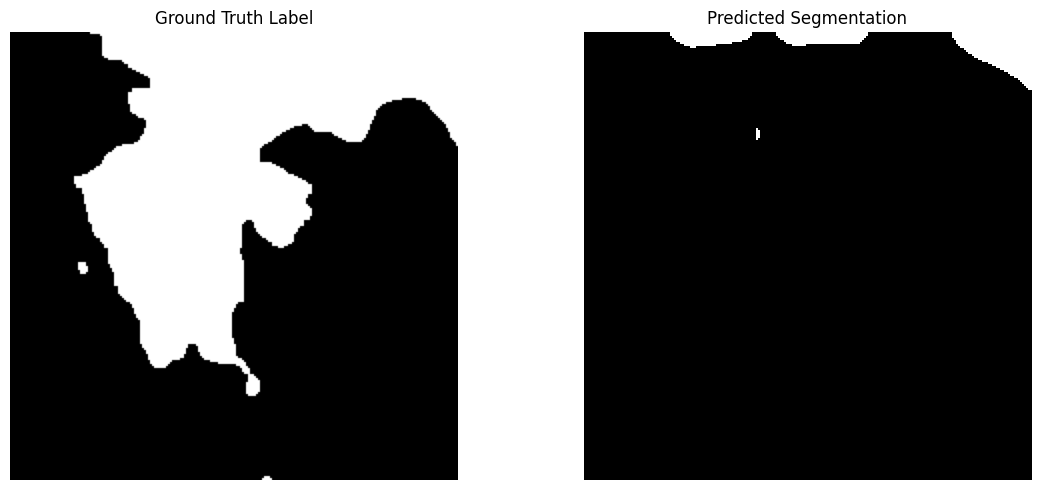

✅ Saved: inference_results/inference_1.png


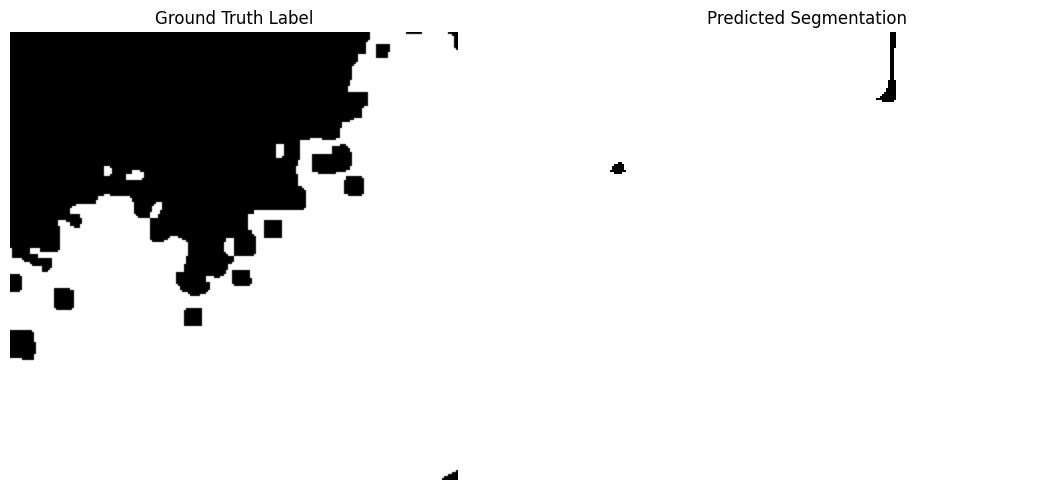

✅ Saved: inference_results/inference_2.png


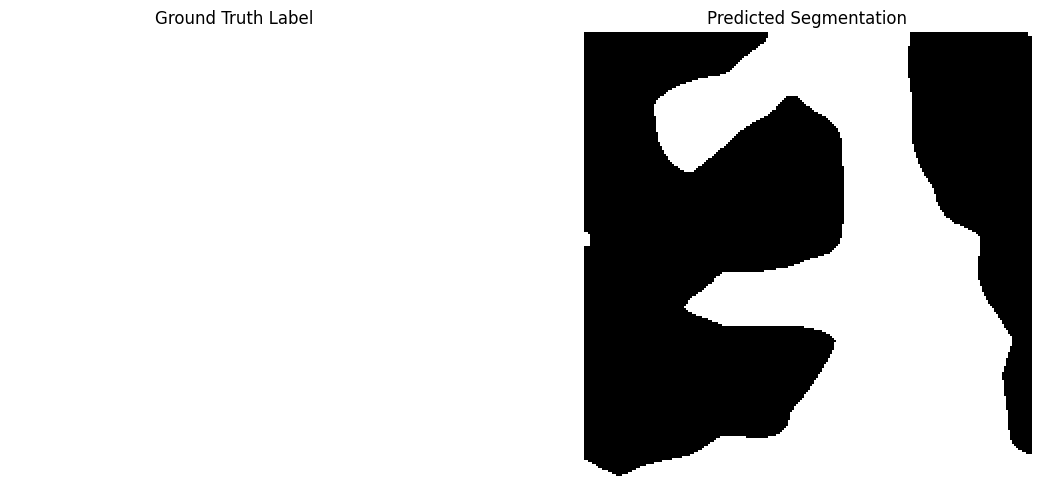

✅ Saved: inference_results/inference_3.png


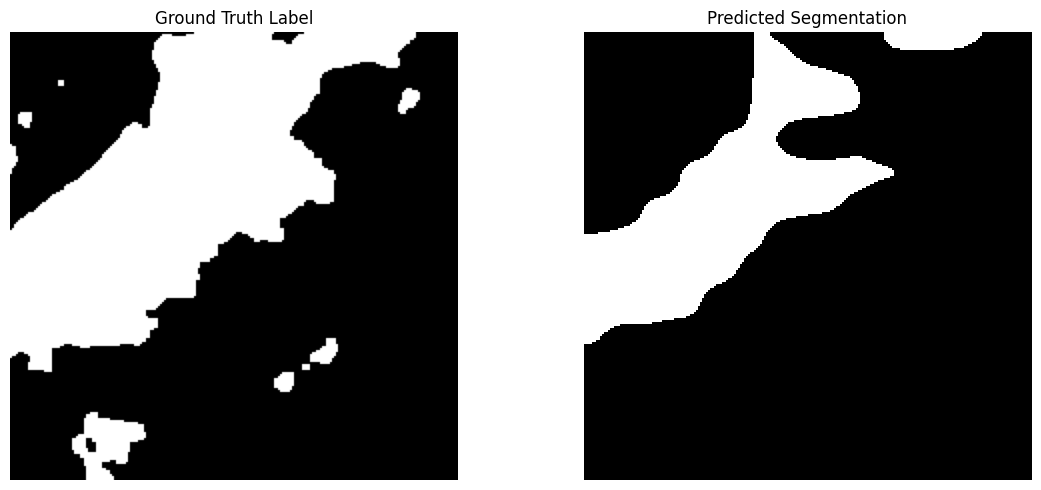

✅ Saved: inference_results/inference_4.png


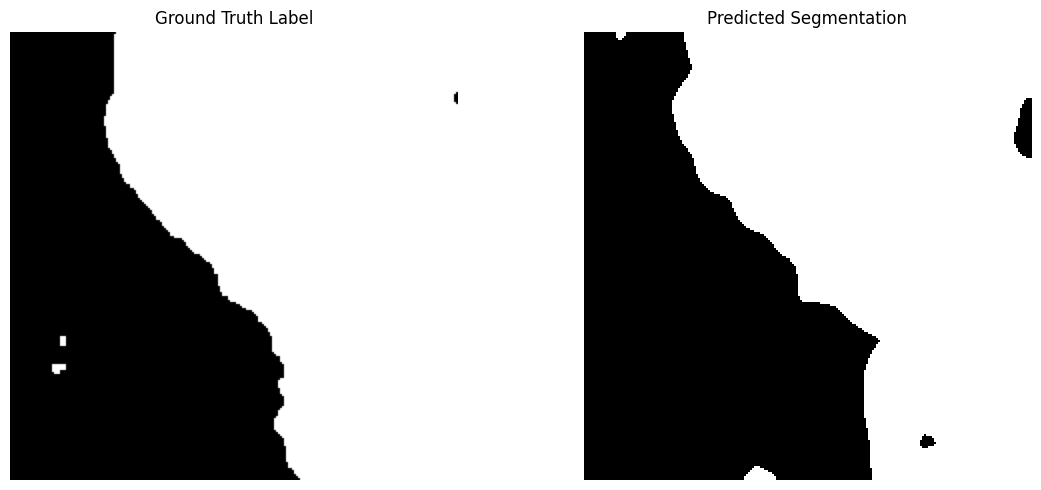

✅ Saved: inference_results/inference_5.png


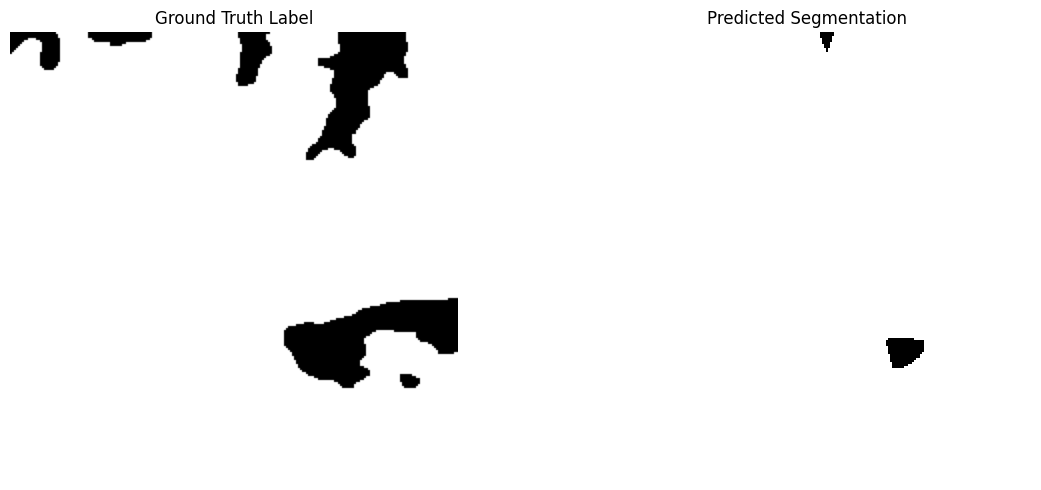

✅ Saved: inference_results/inference_6.png


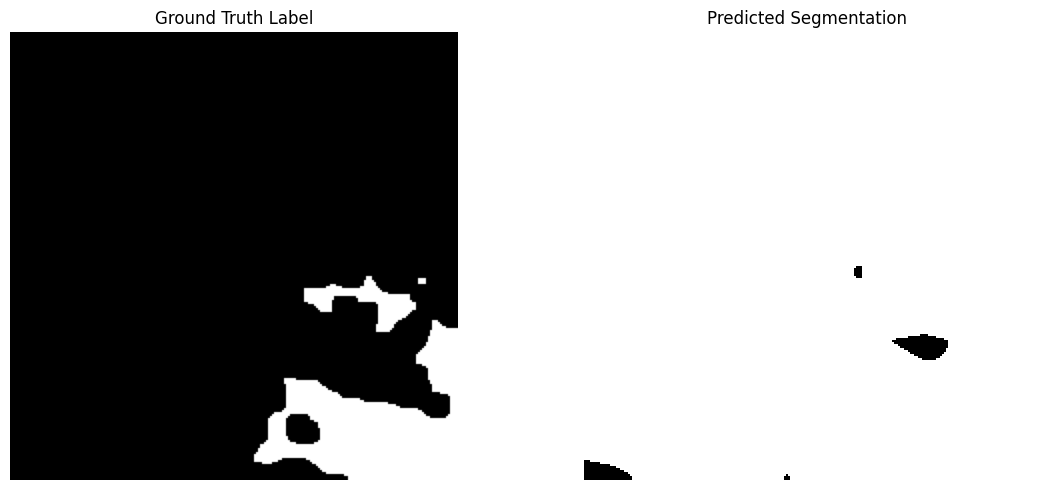

✅ Saved: inference_results/inference_7.png


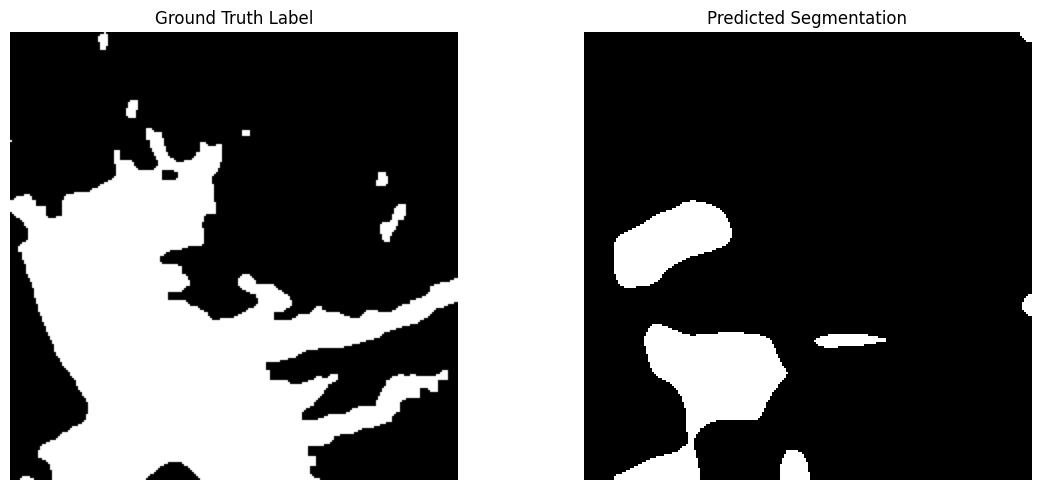

✅ Saved: inference_results/inference_8.png


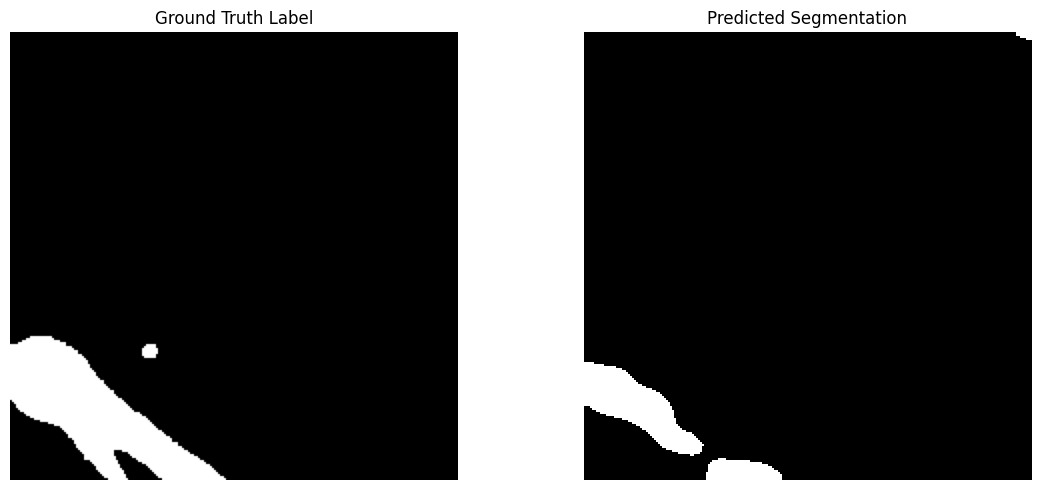

✅ Saved: inference_results/inference_9.png


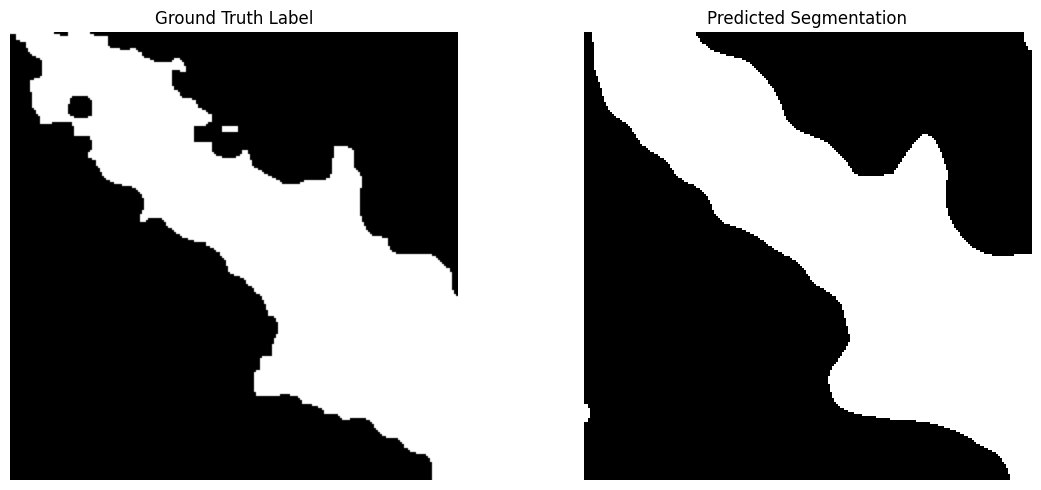

✅ Saved: inference_results/inference_10.png

PREDICTION STATISTICS

Image 1: FID26_Q3_2023_S1_Reservoir_Batch_01_170925_tile_x0_y224.png
  Classes: [0 1]
  Pixels: [49002  1174]
  Percentage: ['97.66%', '2.34%']

Image 2: FID278_Q4_2022_S1_280925_tile_x0_y0.png
  Classes: [0 1]
  Pixels: [  150 50026]
  Percentage: ['0.30%', '99.70%']

Image 3: FID189_Q2_2021_S1_280925_tile_x0_y224.png
  Classes: [0 1]
  Pixels: [27888 22288]
  Percentage: ['55.58%', '44.42%']

Image 4: FID321_Q3_2016_S1_280925_tile_x224_y448.png
  Classes: [0 1]
  Pixels: [40946  9230]
  Percentage: ['81.60%', '18.40%']

Image 5: FID305_Q2_2023_S1_280925_tile_x672_y224.png
  Classes: [0 1]
  Pixels: [21777 28399]
  Percentage: ['43.40%', '56.60%']

Image 6: FID306_Q1_2025_S1_280925_tile_x448_y672.png
  Classes: [0 1]
  Pixels: [  262 49914]
  Percentage: ['0.52%', '99.48%']

Image 7: FID345_Q1_2022_S1_280925_tile_x224_y0.png
  Classes: [0 1]
  Pixels: [  435 49741]
  Percentage: ['0.87%', '99.13%']

Image 8: FID6_Q3_2

In [44]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import rasterio
import random
from pathlib import Path

# Assumes extract_patch_features and SegmentationDataset are already defined in your notebook
# If not, import them:
# from your_training_file import extract_patch_features
# from your_dataset_file import SegmentationDataset

# ============================================================================
# CONFIGURATION
# ============================================================================

CHECKPOINT_PATH = '/home/arm/Desktop/ARM/Codes/DOFA/checkpoints/checkpoint_epoch_batchsize100_5.pth'
root_dir='/home/arm/Documents/ARM/tiled_dataset'
VV_DIR='/home/arm/Documents/ARM/tiled_dataset/vv'
VH_DIR='/home/arm/Documents/ARM/tiled_dataset/vh'
labels_dir='/home/arm/Documents/ARM/tiled_dataset/labels'
NUM_IMAGES = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sentinel-1 constants
S1_MEAN = [166.36275909, 88.45542715]
S1_STD = [64.83126309, 43.07350145]
WAVELENGTHS = [3.75, 3.75]

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_checkpoint(checkpoint_path, vit_model, decoder, device='cuda'):
    """Load trained decoder weights from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device,weights_only=False)
    decoder.load_state_dict(checkpoint['decoder_state_dict'])
    
    vit_model.eval()
    decoder.eval()
    
    print(f"✅ Loaded checkpoint from epoch {checkpoint['epoch']}")
    print(f"   Best IoU: {checkpoint['metrics']['iou']:.4f}")
    
    return vit_model, decoder


def get_random_image_pairs(vv_dir, vh_dir, labels_dir, num_images=10):
    """Get random matching VV and VH image pairs by FID"""
    vv_dir = Path(vv_dir)
    vh_dir = Path(vh_dir)
    labels_dir = Path(labels_dir)
    
    def extract_fid(filename):
        stem = Path(filename).stem
        parts = stem.split('_')
        if len(parts) >= 3:
            return '_'.join(parts[:3])
        return stem
    
    # Collect VV files
    vv_files = {}
    for f in vv_dir.glob('*'):
        if f.is_file() and f.suffix.lower() in ['.png', '.tif', '.tiff']:
            fid = extract_fid(f.name)
            vv_files[fid] = f
    
    # Collect VH files
    vh_files = {}
    for f in vh_dir.glob('*'):
        if f.is_file() and f.suffix.lower() in ['.png', '.tif', '.tiff']:
            fid = extract_fid(f.name)
            vh_files[fid] = f
    labels_files = {}
    for f in labels_dir.glob('*'):
        if f.is_file() and f.suffix.lower() in ['.png', '.tif', '.tiff']:
            fid = extract_fid(f.name)
            labels_files[fid] = f
    
    # Find common FIDs
    common_fids = set(vv_files.keys()) & set(vh_files.keys())
    
    if len(common_fids) == 0:
        raise ValueError("No matching VV/VH pairs found!")
    
    print(f"Found {len(common_fids)} matching VV/VH pairs")
    
    # Sample random pairs
    num_to_sample = min(num_images, len(common_fids))
    sampled_fids = list(common_fids)[:10]
    
    vv_paths = [str(vv_files[fid]) for fid in sampled_fids]
    vh_paths = [str(vh_files[fid]) for fid in sampled_fids]
    labels_paths = [str(labels_files[fid]) for fid in sampled_fids]

    
    return vv_paths, vh_paths, labels_paths


def run_inference(vit_model, decoder, vv_paths, vh_paths, labels_paths, device='cuda'):
    """Run inference on Sentinel-1 image pairs using dataset preprocessing"""
    from pathlib import Path
    import tempfile
    import shutil
    
    vit_model.eval()
    decoder.eval()
    
    results = []
    
    # Create temporary directories for dataset loader
    temp_dir = tempfile.mkdtemp()
    temp_vv = os.path.join(temp_dir, 'vv')
    temp_vh = os.path.join(temp_dir, 'vh')
    temp_labels = os.path.join(temp_dir, 'labels')  # ✅ Changed
    os.makedirs(temp_vv, exist_ok=True)
    os.makedirs(temp_vh, exist_ok=True)
    os.makedirs(temp_labels, exist_ok=True)  # ✅ Changed
    
    try:
        # Copy files to temp with matching FIDs
        for idx, (vv_path, vh_path,labels_path) in enumerate(zip(vv_paths, vh_paths,labels_paths)):
            # Use .png extension to match dataset glob pattern
            base_name = f'FID{idx}_Q1_2015.png'  # ✅ Consistent .png
            
            shutil.copy(vv_path, os.path.join(temp_vv, base_name))
            shutil.copy(vh_path, os.path.join(temp_vh, base_name))
            shutil.copy(vh_path, os.path.join(temp_labels, base_name))

            
            
        
        # ✅ Create dataset with temp_dir
        dataset = SegmentationDataset(
            root_dir=temp_dir,  # ✅ Fixed!
            image_size=224,
            mean=S1_MEAN,
            std=S1_STD
        )
        
        # Run inference
        with torch.no_grad():
            for idx, sample in enumerate(dataset):
                image = sample['image'].unsqueeze(0).to(device)  # [1, 2, H, W]
                
                # Extract features using your existing function
                features = extract_patch_features(vit_model, image, WAVELENGTHS)
                
                # Decode to segmentation
                target_size = image.shape[-2:]
                logits = decoder(features, target_size)
                
                # Get predictions
                pred_mask = torch.argmax(logits, dim=1).cpu().numpy()[0]
                probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
                
                results.append({
                    'vv_path': vv_paths[idx],
                    'vh_path': vh_paths[idx],
                    'labels_path': labels_paths[idx],
                    'prediction': pred_mask,
                    'probabilities': probs
                })
    
    finally:
        # Cleanup temp directory
        shutil.rmtree(temp_dir)
    
    return results

def visualize_results(results, save_dir='inference_results'):
    """Visualize predictions - labels and predictions only (normalized)"""
    os.makedirs(save_dir, exist_ok=True)

    for idx, result in enumerate(results):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        with rasterio.open(result['labels_path']) as f:
            label = f.read(1)

        # Normalize label to binary [0, 1]
        label_binary = (label > 0).astype('uint8')

        pred_mask = result['prediction']

        # --- 1. Ground Truth Label ---
        axes[0].imshow(label_binary, cmap='gray', vmin=0, vmax=1)
        axes[0].set_title('Ground Truth Label')
        axes[0].axis('off')

        # --- 2. Predicted Mask ---
        axes[1].imshow(pred_mask, cmap='gray', vmin=0, vmax=1)
        axes[1].set_title('Predicted Segmentation')
        axes[1].axis('off')



        plt.tight_layout()
        save_path = os.path.join(save_dir, f'inference_{idx+1}.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        print(f"✅ Saved: {save_path}")



def print_statistics(results):
    """Print prediction statistics"""
    print("\n" + "=" * 60)
    print("PREDICTION STATISTICS")
    print("=" * 60)
    for idx, result in enumerate(results):
        pred = result['prediction']
        unique_classes, counts = np.unique(pred, return_counts=True)
        percentages = (counts / pred.size) * 100
        
        vv_name = Path(result['vv_path']).name
        print(f"\nImage {idx+1}: {vv_name}")
        print(f"  Classes: {unique_classes}")
        print(f"  Pixels: {counts}")
        print(f"  Percentage: {[f'{p:.2f}%' for p in percentages]}")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 60)
print("SENTINEL-1 SEGMENTATION INFERENCE")
print("=" * 60)


vit_model = vit_base_patch16().to(DEVICE)
decoder = DOFAUPerNet(num_classes=2).to(DEVICE)

# Load checkpoint
vit_model, decoder = load_checkpoint(CHECKPOINT_PATH, vit_model, decoder, DEVICE)

# Get random image pairs
print(f"\n📂 Loading {NUM_IMAGES} random VV/VH pairs")
vv_paths, vh_paths, labels_paths = get_random_image_pairs(VV_DIR, VH_DIR, labels_dir, NUM_IMAGES)

# Run inference
print("\n🚀 Running inference...")
results = run_inference(vit_model, decoder, vv_paths, vh_paths, labels_paths, DEVICE)

# Visualize
print("\n📊 Generating visualizations...")
visualize_results(results)

# Print statistics
print_statistics(results)

print(f"\n✅ Done! Uncomment the code after initializing your models.")

Decoder Test

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# from segmentation_models_pytorch.decoders.upernet.decoder import UPerNetDecoder
# from segmentation_models_pytorch.base import SegmentationHead


# class DOFAUPerNet(nn.Module):
#     """
#     UPerNet decoder for DOFA ViT encoder using SMP's UPerNetDecoder.
    
#     Properly handles ViT's flat feature maps by directly using SMP's decoder.
#     """
#     def __init__(
#         self,
#         encoder_dim: int = 768,
#         decoder_channels: int = 256,
#         num_classes: int = 2,
#         patch_size: int = 16,
#         dropout: float = 0.1,
#     ):
#         super().__init__()
#         self.patch_size = patch_size
#         self.encoder_dim = encoder_dim
        
#         # Encoder channels: [input, block_3, block_5, block_7, block_11]
#         encoder_channels = [3, encoder_dim, encoder_dim, encoder_dim, encoder_dim]
        
#         # Project ViT features to common dimension
#         self.feature_proj = nn.ModuleDict({
#             'block_3': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
#             'block_5': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
#             'block_7': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
#             'block_11': nn.Conv2d(encoder_dim, encoder_dim, 1, bias=False),
#         })
        
#         # SMP UPerNet decoder
#         self.decoder = UPerNetDecoder(
#             encoder_channels=encoder_channels,
#             encoder_depth=4,
#             decoder_channels=decoder_channels,
#             use_norm="batchnorm",
#         )
        
#         # Segmentation head
#         self.segmentation_head = SegmentationHead(
#             in_channels=decoder_channels,
#             out_channels=num_classes,
#             activation=None,
#             kernel_size=1,
#             upsampling=4,  # Upsample 4x (from 56x56 to 224x224)
#         )
        
#         self.dropout = nn.Dropout2d(dropout)
    
#     def reshape_vit_features(self, features: torch.Tensor, H: int, W: int) -> torch.Tensor:
#         """Reshape ViT features from (B, N, D) to (B, D, H, W)."""
#         B, N, D = features.shape
#         if N != H * W:
#             raise ValueError(f"Expected {H*W} patches, got {N}")
#         return features.transpose(1, 2).reshape(B, D, H, W)
    
#     def forward(
#         self, 
#         features_dict: dict, 
#         target_size: tuple,
#         dummy_input: torch.Tensor = None
#     ) -> torch.Tensor:
#         """
#         Forward pass through UPerNet decoder.
        
#         Args:
#             features_dict: Dict with 'block_3', 'block_5', 'block_7', 'block_11'
#             target_size: Output size (H, W)
#             dummy_input: Optional dummy input for compatibility
        
#         Returns:
#             Segmentation logits (B, num_classes, H, W)
#         """
#         # Get spatial dimensions
#         B, N, D = features_dict['block_11'].shape
#         H = W = int(np.sqrt(N))  # 14 for 224x224 input
        
#         # Reshape and project all features
#         feat_3 = self.feature_proj['block_3'](
#             self.reshape_vit_features(features_dict['block_3'], H, W)
#         )
#         feat_5 = self.feature_proj['block_5'](
#             self.reshape_vit_features(features_dict['block_5'], H, W)
#         )
#         feat_7 = self.feature_proj['block_7'](
#             self.reshape_vit_features(features_dict['block_7'], H, W)
#         )
#         feat_11 = self.feature_proj['block_11'](
#             self.reshape_vit_features(features_dict['block_11'], H, W)
#         )
        
#         # Create or resize dummy input to match feature resolution
#         if dummy_input is None:
#             dummy_input = torch.zeros(B, 3, H, W, device=feat_3.device, dtype=feat_3.dtype)
#         else:
#             dummy_input = F.interpolate(
#                 dummy_input, 
#                 size=(H, H), 
#                 mode='bilinear', 
#                 align_corners=False
#             )
        
#         # CRITICAL: SMP UPerNetDecoder expects a LIST as single argument
#         features_list = [dummy_input, feat_3, feat_5, feat_7, feat_11]
        
#         # Pass the list (NOT unpacked with *)
#         decoder_out = self.decoder(features_list)
        
#         # Apply dropout
#         x = self.dropout(decoder_out)
        
#         # Segmentation head
#         x = self.segmentation_head(x)
        
#         # Final interpolation to exact target size
#         x = F.interpolate(
#             x,
#             size=target_size,
#             mode='bilinear',
#             align_corners=False
#         )
        
#         return x


# # ============================================================================
# # Test the decoder
# # ============================================================================
# if __name__ == "__main__":
#     print("Testing DOFAUPerNet decoder with SMP's UPerNetDecoder...")
    
#     # Configuration
#     batch_size = 2
#     image_size = 224
#     patch_size = 16
#     num_patches = image_size // patch_size  # 14
#     encoder_dim = 768
#     num_classes = 2
    
#     print(f"Batch size: {batch_size}")
#     print(f"Image size: {image_size}x{image_size}")
#     print(f"Patch size: {patch_size}")
#     print(f"Number of patches: {num_patches}x{num_patches} = {num_patches**2}")
    
#     # Create dummy ViT features
#     features_dict = {
#         'block_3': torch.randn(batch_size, num_patches**2, encoder_dim),
#         'block_5': torch.randn(batch_size, num_patches**2, encoder_dim),
#         'block_7': torch.randn(batch_size, num_patches**2, encoder_dim),
#         'block_11': torch.randn(batch_size, num_patches**2, encoder_dim),
#     }
    
#     # Target output size
#     target_size = (image_size, image_size)
    
#     # Create decoder
#     try:
#         decoder = DOFAUPerNet(
#             encoder_dim=encoder_dim,
#             decoder_channels=256,
#             num_classes=num_classes,
#             patch_size=patch_size,
#             dropout=0.1
#         )
        
#         print(f"\nDecoder created with {sum(p.numel() for p in decoder.parameters()):,} parameters")
        
#         # Forward pass
#         with torch.no_grad():
#             output = decoder(features_dict, target_size)
        
#         print(f"\n✅ Test PASSED!")
#         print(f"Output shape: {output.shape}")
#         print(f"Expected: torch.Size([{batch_size}, {num_classes}, {target_size[0]}, {target_size[1]}])")
        
#         # Verify shape
#         assert output.shape == (batch_size, num_classes, target_size[0], target_size[1])
#         print(f"✅ Shape verification PASSED!")
#         print(f"\n🎉 SMP UPerNet decoder is ready for training!")
        
#     except Exception as e:
#         print(f"\n❌ Test FAILED!")
#         print(f"Error: {type(e).__name__}: {e}")
#         import traceback
#         traceback.print_exc()

Testing DOFAUPerNet decoder with SMP's UPerNetDecoder...
Batch size: 2
Image size: 224x224
Patch size: 16
Number of patches: 14x14 = 196

Decoder created with 10,627,074 parameters

✅ Test PASSED!
Output shape: torch.Size([2, 2, 224, 224])
Expected: torch.Size([2, 2, 224, 224])
✅ Shape verification PASSED!

🎉 SMP UPerNet decoder is ready for training!


In [12]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from matplotlib.colors import ListedColormap
import os
import re
from collections import defaultdict

# Configuration
ensemble_folder = "/data/ARM_Dataset/Organized0_90/recluster/ensemble"
rgb_folder = "/data/Final_ARM_Dataset/input"
ensemble_pattern = r"^(FID\d+)_Q\d_\d{4}_.*ensemble_cleaned\.tif$"
rgb_pattern = r"^(FID\d+)_.*\.tif$"

band_config = {'red': 2, 'green': 7, 'blue': 3}

# Custom colormap: 0=white, 1=blue
colors = ['white', 'blue']
cmap = ListedColormap(colors)

def find_optimal_threshold(region_sizes, num_features):
    """
    Find optimal threshold by detecting the largest gap between histogram bins.
    Sets threshold at the START of the gap (end of noise).
    """
    mean_size = region_sizes.mean()
    median_size = np.median(region_sizes)
    
    # Histogram Bin Gap Analysis
    num_bins = min(50, max(20, num_features // 5))
    hist, bin_edges = np.histogram(region_sizes, bins=num_bins)
    
    zero_bins = np.where(hist == 0)[0]
    
    # Group consecutive zero bins into gap regions
    gaps = []
    if len(zero_bins) > 0:
        gap_start = zero_bins[0]
        gap_end = zero_bins[0]
        
        for i in range(1, len(zero_bins)):
            if zero_bins[i] == zero_bins[i-1] + 1:
                gap_end = zero_bins[i]
            else:
                gaps.append({
                    'start_bin': gap_start,
                    'end_bin': gap_end,
                    'start_value': bin_edges[gap_start],
                    'end_value': bin_edges[gap_end + 1],
                    'width': gap_end - gap_start + 1,
                    'center': (bin_edges[gap_start] + bin_edges[gap_end + 1]) / 2
                })
                gap_start = zero_bins[i]
                gap_end = zero_bins[i]
        
        gaps.append({
            'start_bin': gap_start,
            'end_bin': gap_end,
            'start_value': bin_edges[gap_start],
            'end_value': bin_edges[gap_end + 1],
            'width': gap_end - gap_start + 1,
            'center': (bin_edges[gap_start] + bin_edges[gap_end + 1]) / 2
        })
    
    # Filter valid gaps
    max_value = region_sizes.max()
    valid_gaps = []
    
    for gap in gaps:
        has_data_before = gap['start_bin'] > 0 and hist[gap['start_bin'] - 1] > 0
        has_data_after = gap['end_bin'] < len(hist) - 1 and hist[gap['end_bin'] + 1] > 0
        in_lower_range = gap['center'] < max_value * 0.8
        
        if has_data_before and has_data_after and in_lower_range:
            valid_gaps.append(gap)
    
    if len(valid_gaps) > 0:
        valid_gaps.sort(key=lambda x: (x['width'], -x['center']), reverse=True)
        best_gap = valid_gaps[0]
        gap_threshold = best_gap['start_value']
        method = f"Gap Start ({best_gap['width']} bins)"
    else:
        gap_threshold = None
        method = None
    
    # Fallback methods
    sorted_sizes = np.sort(region_sizes)
    gaps_between = np.diff(sorted_sizes)
    lower_half_idx = len(sorted_sizes) // 2
    lower_gaps = gaps_between[:lower_half_idx]
    
    if len(lower_gaps) > 0:
        max_gap_idx = np.argmax(lower_gaps)
        gap_size = lower_gaps[max_gap_idx]
        jump_threshold = sorted_sizes[max_gap_idx]
        
        if gap_size > 5 * np.median(lower_gaps):
            method_jump = f"Size Jump"
        else:
            jump_threshold = None
    else:
        jump_threshold = None
    
    p10 = np.percentile(region_sizes, 10)
    p20 = np.percentile(region_sizes, 20)
    
    if gap_threshold is not None:
        final_threshold = gap_threshold
        final_method = method
    elif jump_threshold is not None:
        final_threshold = jump_threshold
        final_method = method_jump
    else:
        if mean_size > median_size * 3:
            final_threshold = p10
            final_method = "P10"
        else:
            final_threshold = p20
            final_method = "P20"
    
    # Safety checks
    if mean_size > median_size:
        min_acceptable = median_size
        if final_threshold < min_acceptable:
            final_threshold = min_acceptable
            final_method = f"{final_method}→Median"
    
    if final_threshold < p10:
        final_threshold = p10
        final_method = f"{final_method}→P10"
    
    return final_threshold, final_method

# Step 1: Find all ensemble files and group by FID
print("Step 1: Scanning ensemble files...")
ensemble_by_fid = defaultdict(list)

for filename in os.listdir(ensemble_folder):
    if filename.endswith("ensemble_cleaned.tif"):
        match = re.match(ensemble_pattern, filename)
        if match:
            fid = match.group(1)
            full_path = os.path.join(ensemble_folder, filename)
            ensemble_by_fid[fid].append({
                'path': full_path,
                'filename': filename
            })

print(f"Found {len(ensemble_by_fid)} unique FIDs with ensemble files")

# Step 2: Find corresponding RGB files
print("\nStep 2: Matching RGB files...")
rgb_by_fid = {}

for filename in os.listdir(rgb_folder):
    if filename.endswith(".tif"):
        match = re.match(rgb_pattern, filename)
        if match:
            fid = match.group(1)
            if fid in ensemble_by_fid:
                full_path = os.path.join(rgb_folder, filename)
                rgb_by_fid[fid] = {
                    'path': full_path,
                    'filename': filename
                }

print(f"Found {len(rgb_by_fid)} matching RGB files")

# Step 3: Filter valid ensemble files with components
print("\nStep 3: Filtering valid ensemble files...")
valid_files = []

for fid in sorted(ensemble_by_fid.keys()):
    if fid not in rgb_by_fid:
        continue
    
    print(f"\nProcessing {fid}:")
    rgb_info = rgb_by_fid[fid]
    
    for ensemble_info in ensemble_by_fid[fid]:
        try:
            with rasterio.open(ensemble_info['path']) as src:
                image = src.read(1)
                structure = np.ones((3, 3), dtype=int)
                labeled_array, num_features = label(image == 1, structure=structure)
                
                if num_features > 0:
                    valid_files.append({
                        'fid': fid,
                        'rgb': rgb_info,
                        'ensemble': ensemble_info
                    })
                    print(f"  ✓ {ensemble_info['filename']} ({num_features} components)")
                else:
                    print(f"  ✗ {ensemble_info['filename']} (no components)")
        except Exception as e:
            print(f"  ✗ {ensemble_info['filename']} (error: {e})")

print(f"\n{'='*70}")
print(f"Total valid files: {len(valid_files)}")
print(f"{'='*70}\n")

if len(valid_files) == 0:
    print("No valid files to process!")
    exit()

# 4 rows × 8 images = 32 images per page (each image has 4 subplots)
images_per_page = 8
num_pages = (len(valid_files) + images_per_page - 1) // images_per_page

print(f"Creating {num_pages} pages with up to {images_per_page} images each (4×8 grid)\n")

# Process files in pages
for page in range(num_pages):
    start_idx = page * images_per_page
    end_idx = min(start_idx + images_per_page, len(valid_files))
    files_to_process = valid_files[start_idx:end_idx]
    
    print(f"\n{'='*70}")
    print(f"Processing Page {page + 1}/{num_pages}: Images {start_idx + 1} to {end_idx}")
    print(f"{'='*70}")
    
    # Create 4 rows × (4 subplots per image) figure
    num_rows = 4
    num_cols = len(files_to_process) * 4  # 4 subplots per image
    fig = plt.figure(figsize=(5*len(files_to_process), 20))
    
    for img_idx, file_info in enumerate(files_to_process):
        fid = file_info['fid']
        rgb_info = file_info['rgb']
        ensemble_info = file_info['ensemble']
        
        print(f"\n  [{img_idx+1}/{len(files_to_process)}] {fid}")
        print(f"      RGB: {rgb_info['filename']}")
        print(f"      Ensemble: {ensemble_info['filename']}")
        
        try:
            # Read RGB image
            with rasterio.open(rgb_info['path']) as src:
                red = src.read(band_config['red'])
                green = src.read(band_config['green'])
                blue = src.read(band_config['blue'])
                
                # Normalize to 0-1 for display
                def normalize_band(band):
                    p2, p98 = np.percentile(band, (2, 98))
                    band = np.clip(band, p2, p98)
                    band = (band - p2) / (p98 - p2)
                    return band
                
                rgb_display = np.dstack([
                    normalize_band(red),
                    normalize_band(green),
                    normalize_band(blue)
                ])
            
            # Read ensemble image
            with rasterio.open(ensemble_info['path']) as src:
                image = src.read(1)
                structure = np.ones((3, 3), dtype=int)
                labeled_array, num_features = label(image == 1, structure=structure)
                region_sizes = np.bincount(labeled_array.ravel())[1:]
                
                # Statistics
                max_size = region_sizes.max()
                mean_size = region_sizes.mean()
                median_size = np.median(region_sizes)
                
                # Find threshold
                threshold, method = find_optimal_threshold(region_sizes, num_features)
                
                # Apply filtering
                filtered_labels = labeled_array.copy()
                for region_id in range(1, num_features + 1):
                    if region_sizes[region_id - 1] < threshold:
                        filtered_labels[filtered_labels == region_id] = 0
                
                cleaned_image = (filtered_labels > 0).astype(np.uint8)
                removed_count = np.sum(region_sizes < threshold)
                kept_count = num_features - removed_count
                
                print(f"      Components: {num_features} | Threshold: {threshold:.0f}px ({method})")
                print(f"      Kept: {kept_count} | Removed: {removed_count}")
            
            # Calculate subplot positions for this image
            base_col = img_idx * 4
            
            # Row 0: RGB
            ax_rgb = plt.subplot2grid((num_rows, num_cols), (0, base_col), colspan=4)
            ax_rgb.imshow(rgb_display)
            ax_rgb.set_title(f'{fid}\nRGB Composite', fontsize=10, fontweight='bold')
            ax_rgb.axis('off')
            
            # Row 1: Input
            ax_input = plt.subplot2grid((num_rows, num_cols), (1, base_col), colspan=4)
            ax_input.imshow(image, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
            ax_input.set_title(f'Input ({num_features} components)', fontsize=10)
            ax_input.axis('off')
            
            # Row 2: Histogram
            ax_hist = plt.subplot2grid((num_rows, num_cols), (2, base_col), colspan=4)
            bins = min(50, len(np.unique(region_sizes)))
            ax_hist.hist(region_sizes, bins=bins, edgecolor='black', 
                        alpha=0.7, color='steelblue', linewidth=1)
            
            ax_hist.axvline(median_size, color='red', linestyle='--', 
                           linewidth=1.5, alpha=0.7, label=f'Median: {median_size:.0f}')
            ax_hist.axvline(threshold, color='green', linestyle='-', 
                           linewidth=2.5, alpha=0.9, label=f'T: {threshold:.0f}')
            ax_hist.axvspan(0, threshold, alpha=0.2, color='red')
            
            ax_hist.set_xlabel('Size (pixels)', fontsize=9)
            ax_hist.set_ylabel('Frequency', fontsize=9)
            ax_hist.set_title(f'Distribution ({method})', fontsize=10)
            ax_hist.legend(fontsize=8)
            ax_hist.grid(True, alpha=0.3)
            
            if num_features > 50:
                ax_hist.set_yscale('log')
            
            # Row 3: Cleaned
            ax_clean = plt.subplot2grid((num_rows, num_cols), (3, base_col), colspan=4)
            ax_clean.imshow(cleaned_image, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
            ax_clean.set_title(f'Cleaned ({kept_count} kept, {removed_count} removed)', 
                              fontsize=10, fontweight='bold', color='green')
            ax_clean.axis('off')
            
        except Exception as e:
            print(f"      ❌ Error: {str(e)}")
            base_col = img_idx * 4
            for row in range(num_rows):
                ax_err = plt.subplot2grid((num_rows, num_cols), (row, base_col), colspan=4)
                ax_err.axis('off')
                if row == 1:
                    ax_err.text(0.5, 0.5, f'Error:\n{str(e)}', 
                               ha='center', va='center', 
                               transform=ax_err.transAxes,
                               fontsize=8, color='red')
    
    fig.suptitle(f'RGB + Threshold Analysis - Page {page + 1}/{num_pages}', 
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    output_filename = f'rgb_threshold_page_{page + 1:03d}.png'
    plt.savefig(output_filename, dpi=150, bbox_inches='tight')
    print(f"\n  ✅ Saved: {output_filename}")
    plt.close()

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print(f"\nLayout: 4 rows × 8 columns (8 images per page)")
print("Each image column shows: RGB | Input | Histogram | Cleaned")
print("="*70)

Step 1: Scanning ensemble files...
Found 27 unique FIDs with ensemble files

Step 2: Matching RGB files...
Found 27 matching RGB files

Step 3: Filtering valid ensemble files...

Processing FID0:
  ✗ FID0_Q2_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (no components)

Processing FID10:
  ✓ FID10_Q2_2023_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (932 components)

Processing FID19:
  ✗ FID19_Q1_2020_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (no components)

Processing FID3:
  ✓ FID3_Q2_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (455 components)
  ✓ FID3_Q2_2020_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (473 components)

Processing FID32:
  ✓ FID32_Q3_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (66 components)

Processing FID34:
  ✓ FID34_Q2_2023_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (713 components)

Processing FID35:
  ✓ FID35_Q1_2016_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (181 components)

Processing FID37

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


      Components: 932 | Threshold: 31474px (Gap Start (48 bins))
      Kept: 1 | Removed: 931

  [2/8] FID3
      RGB: FID3_Q1_2021_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID3_Q2_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif
      Components: 455 | Threshold: 20559px (Gap Start (48 bins))
      Kept: 1 | Removed: 454

  [3/8] FID3
      RGB: FID3_Q1_2021_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID3_Q2_2020_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


      Components: 473 | Threshold: 20882px (Gap Start (48 bins))
      Kept: 1 | Removed: 472

  [4/8] FID32
      RGB: FID32_Q3_2016_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID32_Q3_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif
      Components: 66 | Threshold: 1598px (Gap Start (18 bins))
      Kept: 1 | Removed: 65

  [5/8] FID34
      RGB: FID34_Q4_2019_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID34_Q2_2023_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif
      Components: 713 | Threshold: 5528px (Gap Start (46 bins))
      Kept: 1 | Removed: 712


...

      Components: 342 | Threshold: 18285px (Gap Start (46 bins))
      Kept: 1 | Removed: 341

  [5/8] FID72
      RGB: FID72_Q3_2017_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID72_Q2_2021_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif
      Components: 37 | Threshold: 3168px (Gap Start (17 bins))
      Kept: 1 | Removed: 36

  [6/8] FID76
      RGB: FID76_Q1_2025_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID76_Q2_2021_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif
      Components: 279 | Threshold: 82120px (Gap Start (42 bins))
      Kept: 1 | Removed: 278

  [7/8] FID76
      RGB: FID76_Q1_2025_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID76_Q1_2021_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif
      Components: 270 | Threshold: 57995px (Gap Start (44 bins))
      Kept: 1 | Removed: 269

  [8/8] FID76
      RGB: FID76_Q1_2025_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID76_Q2_2020_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif
      Component

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


      Components: 1368 | Threshold: 47555px (Gap Start (13 bins))
      Kept: 4 | Removed: 1364

  [5/6] FID85
      RGB: FID85_Q1_2023_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID85_Q1_2020_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


      Components: 440 | Threshold: 7849px (Gap Start (47 bins))
      Kept: 1 | Removed: 439

  [6/6] FID9
      RGB: FID9_Q1_2019_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID9_Q2_2019_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif
      Components: 33 | Threshold: 2760px (Gap Start (18 bins))
      Kept: 1 | Removed: 32

  ✅ Saved: rgb_threshold_page_005.png

ANALYSIS COMPLETE!

Layout: 4 rows × 8 columns (8 images per page)
Each image column shows: RGB | Input | Histogram | Cleaned


In [13]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from matplotlib.colors import ListedColormap
import os
import re
from collections import defaultdict

# Configuration
ensemble_folder = "/data/ARM_Dataset/Organized0_90/recluster/ensemble"
rgb_folder = "/data/Final_ARM_Dataset/input"
ensemble_pattern = r"^(FID\d+)_Q\d_\d{4}_.*ensemble_cleaned\.tif$"
rgb_pattern = r"^(FID\d+)_.*\.tif$"

band_config = {'red': 2, 'green': 7, 'blue': 3}

# Custom colormap: 0=white, 1=blue
colors = ['white', 'blue']
cmap = ListedColormap(colors)

def find_optimal_threshold(region_sizes, num_features):
    """
    Use mean as threshold.
    """
    mean_size = region_sizes.mean()
    final_threshold = mean_size
    final_method = "Mean"
    
    return final_threshold, final_method

# Step 1: Find all ensemble files and group by FID
print("Step 1: Scanning ensemble files...")
ensemble_by_fid = defaultdict(list)

for filename in os.listdir(ensemble_folder):
    if filename.endswith("ensemble_cleaned.tif"):
        match = re.match(ensemble_pattern, filename)
        if match:
            fid = match.group(1)
            full_path = os.path.join(ensemble_folder, filename)
            ensemble_by_fid[fid].append({
                'path': full_path,
                'filename': filename
            })

print(f"Found {len(ensemble_by_fid)} unique FIDs with ensemble files")

# Step 2: Find corresponding RGB files
print("\nStep 2: Matching RGB files...")
rgb_by_fid = {}

for filename in os.listdir(rgb_folder):
    if filename.endswith(".tif"):
        match = re.match(rgb_pattern, filename)
        if match:
            fid = match.group(1)
            if fid in ensemble_by_fid:
                full_path = os.path.join(rgb_folder, filename)
                rgb_by_fid[fid] = {
                    'path': full_path,
                    'filename': filename
                }

print(f"Found {len(rgb_by_fid)} matching RGB files")

# Step 3: Filter valid ensemble files with components
print("\nStep 3: Filtering valid ensemble files...")
valid_files = []

for fid in sorted(ensemble_by_fid.keys()):
    if fid not in rgb_by_fid:
        continue
    
    print(f"\nProcessing {fid}:")
    rgb_info = rgb_by_fid[fid]
    
    for ensemble_info in ensemble_by_fid[fid]:
        try:
            with rasterio.open(ensemble_info['path']) as src:
                image = src.read(1)
                structure = np.ones((3, 3), dtype=int)
                labeled_array, num_features = label(image == 1, structure=structure)
                
                if num_features > 0:
                    valid_files.append({
                        'fid': fid,
                        'rgb': rgb_info,
                        'ensemble': ensemble_info
                    })
                    print(f"  ✓ {ensemble_info['filename']} ({num_features} components)")
                else:
                    print(f"  ✗ {ensemble_info['filename']} (no components)")
        except Exception as e:
            print(f"  ✗ {ensemble_info['filename']} (error: {e})")

print(f"\n{'='*70}")
print(f"Total valid files: {len(valid_files)}")
print(f"{'='*70}\n")

if len(valid_files) == 0:
    print("No valid files to process!")
    exit()

# 4 rows × 8 images = 32 images per page (each image has 4 subplots)
images_per_page = 8
num_pages = (len(valid_files) + images_per_page - 1) // images_per_page

print(f"Creating {num_pages} pages with up to {images_per_page} images each (4×8 grid)\n")

# Process files in pages
for page in range(num_pages):
    start_idx = page * images_per_page
    end_idx = min(start_idx + images_per_page, len(valid_files))
    files_to_process = valid_files[start_idx:end_idx]
    
    print(f"\n{'='*70}")
    print(f"Processing Page {page + 1}/{num_pages}: Images {start_idx + 1} to {end_idx}")
    print(f"{'='*70}")
    
    # Create 4 rows × (4 subplots per image) figure
    num_rows = 4
    num_cols = len(files_to_process) * 4  # 4 subplots per image
    fig = plt.figure(figsize=(5*len(files_to_process), 20))
    
    for img_idx, file_info in enumerate(files_to_process):
        fid = file_info['fid']
        rgb_info = file_info['rgb']
        ensemble_info = file_info['ensemble']
        
        print(f"\n  [{img_idx+1}/{len(files_to_process)}] {fid}")
        print(f"      RGB: {rgb_info['filename']}")
        print(f"      Ensemble: {ensemble_info['filename']}")
        
        try:
            # Read RGB image
            with rasterio.open(rgb_info['path']) as src:
                red = src.read(band_config['red'])
                green = src.read(band_config['green'])
                blue = src.read(band_config['blue'])
                
                # Normalize to 0-1 for display
                def normalize_band(band):
                    p2, p98 = np.percentile(band, (2, 98))
                    band = np.clip(band, p2, p98)
                    band = (band - p2) / (p98 - p2)
                    return band
                
                rgb_display = np.dstack([
                    normalize_band(red),
                    normalize_band(green),
                    normalize_band(blue)
                ])
            
            # Read ensemble image
            with rasterio.open(ensemble_info['path']) as src:
                image = src.read(1)
                structure = np.ones((3, 3), dtype=int)
                labeled_array, num_features = label(image == 1, structure=structure)
                region_sizes = np.bincount(labeled_array.ravel())[1:]
                
                # Statistics
                max_size = region_sizes.max()
                mean_size = region_sizes.mean()
                median_size = np.median(region_sizes)
                
                # Find threshold (now just returns mean)
                threshold, method = find_optimal_threshold(region_sizes, num_features)
                
                # Apply filtering
                filtered_labels = labeled_array.copy()
                for region_id in range(1, num_features + 1):
                    if region_sizes[region_id - 1] < threshold:
                        filtered_labels[filtered_labels == region_id] = 0
                
                cleaned_image = (filtered_labels > 0).astype(np.uint8)
                removed_count = np.sum(region_sizes < threshold)
                kept_count = num_features - removed_count
                
                print(f"      Components: {num_features} | Threshold: {threshold:.0f}px ({method})")
                print(f"      Kept: {kept_count} | Removed: {removed_count}")
            
            # Calculate subplot positions for this image
            base_col = img_idx * 4
            
            # Row 0: RGB
            ax_rgb = plt.subplot2grid((num_rows, num_cols), (0, base_col), colspan=4)
            ax_rgb.imshow(rgb_display)
            ax_rgb.set_title(f'{fid}\nRGB Composite', fontsize=10, fontweight='bold')
            ax_rgb.axis('off')
            
            # Row 1: Input
            ax_input = plt.subplot2grid((num_rows, num_cols), (1, base_col), colspan=4)
            ax_input.imshow(image, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
            ax_input.set_title(f'Input ({num_features} components)', fontsize=10)
            ax_input.axis('off')
            
            # Row 2: Histogram
            ax_hist = plt.subplot2grid((num_rows, num_cols), (2, base_col), colspan=4)
            bins = min(50, len(np.unique(region_sizes)))
            ax_hist.hist(region_sizes, bins=bins, edgecolor='black', 
                        alpha=0.7, color='steelblue', linewidth=1)
            
            ax_hist.axvline(median_size, color='red', linestyle='--', 
                           linewidth=1.5, alpha=0.7, label=f'Median: {median_size:.0f}')
            ax_hist.axvline(threshold, color='green', linestyle='-', 
                           linewidth=2.5, alpha=0.9, label=f'T: {threshold:.0f}')
            ax_hist.axvspan(0, threshold, alpha=0.2, color='red')
            
            ax_hist.set_xlabel('Size (pixels)', fontsize=9)
            ax_hist.set_ylabel('Frequency', fontsize=9)
            ax_hist.set_title(f'Distribution ({method})', fontsize=10)
            ax_hist.legend(fontsize=8)
            ax_hist.grid(True, alpha=0.3)
            
            if num_features > 50:
                ax_hist.set_yscale('log')
            
            # Row 3: Cleaned
            ax_clean = plt.subplot2grid((num_rows, num_cols), (3, base_col), colspan=4)
            ax_clean.imshow(cleaned_image, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
            ax_clean.set_title(f'Cleaned ({kept_count} kept, {removed_count} removed)', 
                              fontsize=10, fontweight='bold', color='green')
            ax_clean.axis('off')
            
        except Exception as e:
            print(f"      ❌ Error: {str(e)}")
            base_col = img_idx * 4
            for row in range(num_rows):
                ax_err = plt.subplot2grid((num_rows, num_cols), (row, base_col), colspan=4)
                ax_err.axis('off')
                if row == 1:
                    ax_err.text(0.5, 0.5, f'Error:\n{str(e)}', 
                               ha='center', va='center', 
                               transform=ax_err.transAxes,
                               fontsize=8, color='red')
    
    fig.suptitle(f'RGB + Threshold Analysis (Mean) - Page {page + 1}/{num_pages}', 
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    output_filename = f'rgb_threshold_mean_page_{page + 1:03d}.png'
    plt.savefig(output_filename, dpi=150, bbox_inches='tight')
    print(f"\n  ✅ Saved: {output_filename}")
    plt.close()

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print(f"\nLayout: 4 rows × 8 columns (8 images per page)")
print("Each image column shows: RGB | Input | Histogram | Cleaned")
print(f"Threshold method: Mean")
print("="*70)

Step 1: Scanning ensemble files...
Found 27 unique FIDs with ensemble files

Step 2: Matching RGB files...
Found 27 matching RGB files

Step 3: Filtering valid ensemble files...

Processing FID0:
  ✗ FID0_Q2_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (no components)

Processing FID10:
  ✓ FID10_Q2_2023_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (932 components)

Processing FID19:
  ✗ FID19_Q1_2020_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (no components)

Processing FID3:
  ✓ FID3_Q2_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (455 components)
  ✓ FID3_Q2_2020_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (473 components)

Processing FID32:
  ✓ FID32_Q3_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (66 components)

Processing FID34:
  ✓ FID34_Q2_2023_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (713 components)

Processing FID35:
  ✓ FID35_Q1_2016_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif (181 components)

Processing FID37

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


      Components: 932 | Threshold: 1973px (Mean)
      Kept: 20 | Removed: 912

  [2/8] FID3
      RGB: FID3_Q1_2021_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID3_Q2_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif
      Components: 455 | Threshold: 2484px (Mean)
      Kept: 10 | Removed: 445

  [3/8] FID3
      RGB: FID3_Q1_2021_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID3_Q2_2020_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


      Components: 473 | Threshold: 2389px (Mean)
      Kept: 6 | Removed: 467

  [4/8] FID32
      RGB: FID32_Q3_2016_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID32_Q3_2021_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif
      Components: 66 | Threshold: 563px (Mean)
      Kept: 2 | Removed: 64

  [5/8] FID34
      RGB: FID34_Q4_2019_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID34_Q2_2023_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif


...

      Components: 342 | Threshold: 1280px (Mean)
      Kept: 17 | Removed: 325

  [5/8] FID72
      RGB: FID72_Q3_2017_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID72_Q2_2021_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif
      Components: 37 | Threshold: 1003px (Mean)
      Kept: 2 | Removed: 35

  [6/8] FID76
      RGB: FID76_Q1_2025_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID76_Q2_2021_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif
      Components: 279 | Threshold: 2876px (Mean)
      Kept: 9 | Removed: 270

  [7/8] FID76
      RGB: FID76_Q1_2025_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID76_Q1_2021_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif
      Components: 270 | Threshold: 2941px (Mean)
      Kept: 8 | Removed: 262

  [8/8] FID76
      RGB: FID76_Q1_2025_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID76_Q2_2020_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif
      Components: 305 | Threshold: 2608px (Mean)
      Kept: 7 | Removed: 298

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


      Components: 1368 | Threshold: 1021px (Mean)
      Kept: 67 | Removed: 1301

  [5/6] FID85
      RGB: FID85_Q1_2023_S1_Reservoir_Batch_02_190925.tif
      Ensemble: FID85_Q1_2020_S1_Reservoir_Batch_02_190925_ensemble_cleaned.tif


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


      Components: 440 | Threshold: 601px (Mean)
      Kept: 25 | Removed: 415

  [6/6] FID9
      RGB: FID9_Q1_2019_S1_Reservoir_Batch_01_170925.tif
      Ensemble: FID9_Q2_2019_S1_Reservoir_Batch_01_170925_ensemble_cleaned.tif
      Components: 33 | Threshold: 1783px (Mean)
      Kept: 1 | Removed: 32

  ✅ Saved: rgb_threshold_mean_page_005.png

ANALYSIS COMPLETE!

Layout: 4 rows × 8 columns (8 images per page)
Each image column shows: RGB | Input | Histogram | Cleaned
Threshold method: Mean
